In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt

In [10]:
fits_file = "/Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201/1347_0506070201_M1S00100AUX.FIT"

hdul = fits.open(fits_file)
data = hdul['M1AUX1'].data

In [9]:
hdul[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy and
COMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.
COMMENT   Contact the NASA Science Office of Standards and Technology for the   
COMMENT   FITS Definition document #100 and other FITS information.             
ORIGIN  = 'XMM-SOC '           / Processing site                                
DATE    = '2007-04-17T14:07:27' / File creation date                            
FILENAME= '1347_0506070201_M1S00100AUX.FIT' / Filename                          
CREATOR = 'PMS/ODF V2.12'      / FITS generated code                            
CATEGORY= 'XMMODF  '        

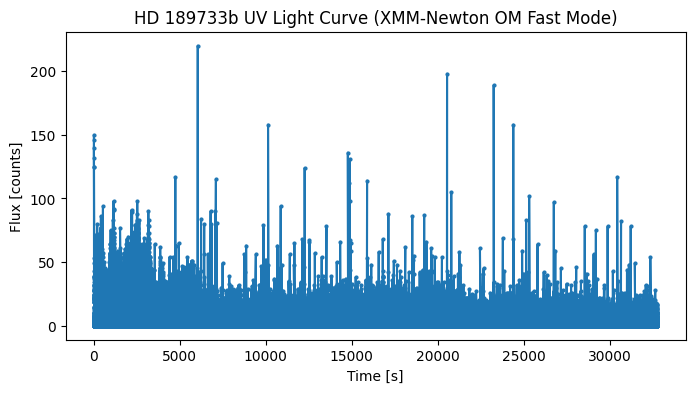

In [11]:
# Construct time (seconds)
time = data['FTCOARSE'] + data['FTFINE']*1e-3  # FTFINE is usually in ms

# Flux (counts)
flux = data['NVALID']

# Plot
plt.figure(figsize=(8,4))
plt.plot(time, flux, 'o-', markersize=2)
plt.xlabel("Time [s]")
plt.ylabel("Flux [counts]")
plt.title("HD 189733b UV Light Curve (XMM-Newton OM Fast Mode)")
plt.show()

In [25]:
 # Código de Diagnóstico: inspecionar_fits.py
from astropy.io import fits

# ATUALIZADO: O nome do arquivo do XMM-Newton que queremos investigar
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT'

print(f"--- Iniciando a inspeção do arquivo: {nome_arquivo_fits} ---\n")

try:
    with fits.open(nome_arquivo_fits) as hdul:
        
        # O método .info() nos dá um resumo rápido da estrutura.
        print("--- Resumo da Estrutura (hdul.info()) ---")
        hdul.info()
        print("\n" + "="*50 + "\n")

        # Agora, vamos olhar em detalhe cada uma das 'extensões' (HDUs).
        for i, hdu in enumerate(hdul):
            print(f"--- Detalhes da Extensão (HDU) número {i} ---")
            
            # Imprime o cabeçalho completo.
            print("\n[CABEÇALHO (HEADER)]")
            print(repr(hdu.header))
            
            # Verifica se a extensão tem dados.
            if hdu.data is not None:
                print("\n[DADOS ENCONTRADOS NESTA EXTENSÃO]")
                if hasattr(hdu.data, 'columns'):
                    print("Nomes das colunas:", hdu.data.columns.names)
                else:
                    print("Formato dos dados (shape):", hdu.data.shape)
            else:
                print("\n[SEM DADOS NESTA EXTENSÃO]")

            print("\n" + "="*50 + "\n")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

--- Iniciando a inspeção do arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT ---

--- Resumo da Estrutura (hdul.info()) ---
Filename: /Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      15   ()      
  1  SCTCS1      1   BinTableHDU     54   2887R x 12C   [1J, 1J, 1I, 1I, 1J, 1I, 39A, 39A, 1I, 27A, 5A, 27A]   


--- Detalhes da Extensão (HDU) número 0 ---

[CABEÇALHO (HEADER)]
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy an

In [ ]:
/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps

Arquivo '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' lido com sucesso!
Total de 440 pontos de dados extraídos.


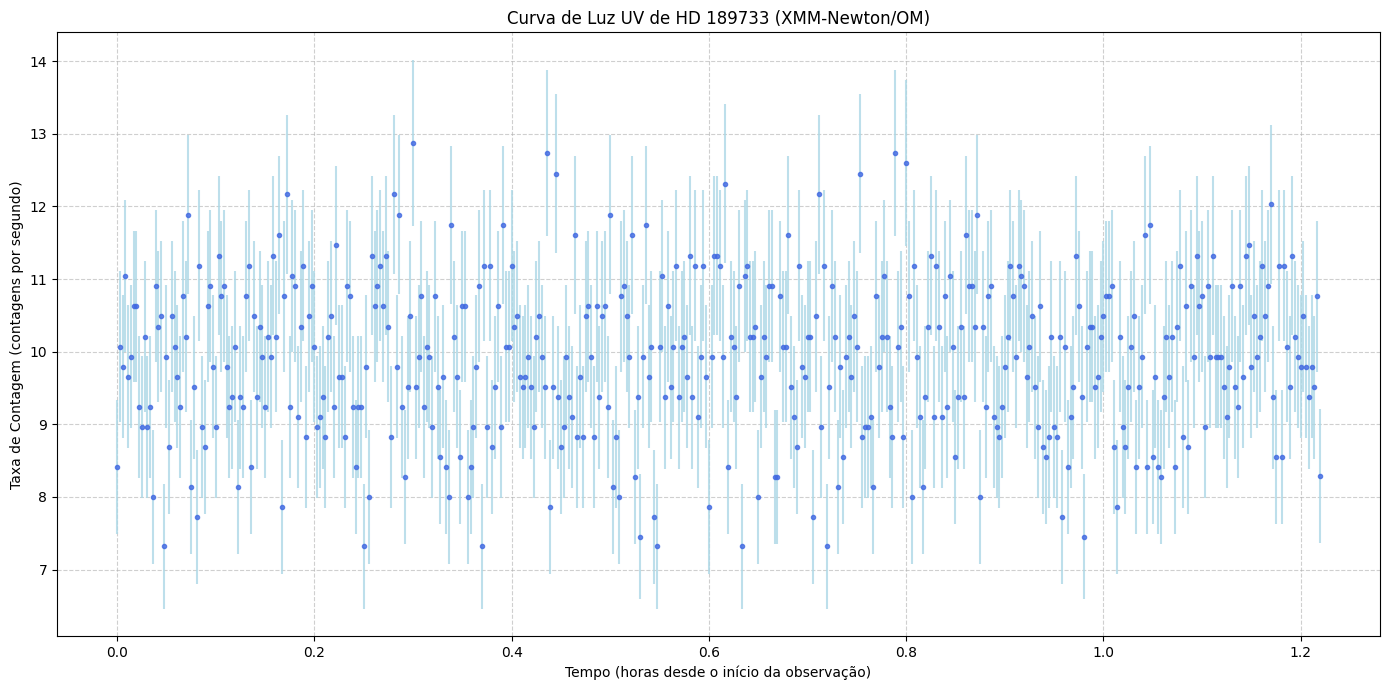

In [1]:
# Script para analisar e plotar a curva de luz do XMM-Newton/OM
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- PASSO 1: CONFIGURAÇÃO ---
# Nome do arquivo de curva de luz que você encontrou!
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

# Nomes de coluna padrão para curvas de luz do XMM-Newton/OM.
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE' # 'RATE' (taxa de contagens/segundo) é o fluxo
coluna_erro  = 'ERROR'

# --- PASSO 2: ABRIR O ARQUIVO E EXTRAIR OS DADOS ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        # A curva de luz está na primeira extensão de tabela (HDU 1)
        dados_tabela = hdul[1].data
        
        # Extrai os dados das colunas
        tempos = dados_tabela[coluna_tempo]
        fluxos = dados_tabela[coluna_fluxo]
        erros_fluxo = dados_tabela[coluna_erro]
        
        print(f"Arquivo '{nome_arquivo_fits}' lido com sucesso!")
        print(f"Total de {len(tempos)} pontos de dados extraídos.")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
    print("Verifique se o nome do arquivo está correto e se ele está na mesma pasta do script.")
    exit()
except KeyError as e:
    print(f"ERRO: A coluna {e} não foi encontrada no arquivo.")
    print("Use o script 'inspecionar_fits.py' para ver os nomes corretos das colunas e ajuste o script, se necessário.")
    exit()

# --- PASSO 3: PLOTAR A CURVA DE LUZ ---
# Converte o tempo de segundos (padrão do XMM) para horas para melhor visualização
tempos_em_horas = (tempos - tempos[0]) / 3600.0

plt.figure(figsize=(14, 7))
plt.errorbar(tempos_em_horas, fluxos, yerr=erros_fluxo, fmt='o', markersize=3, color='royalblue', ecolor='lightblue', capsize=0, alpha=0.8)
plt.title('Curva de Luz UV de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [1]:
# Código de Diagnóstico: inspecionar_fits.py
from astropy.io import fits

# ATUALIZADO: O nome do arquivo de CURVA DE LUZ do XMM-Newton
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

print(f"--- Iniciando a inspeção do arquivo: {nome_arquivo_fits} ---\n")

try:
    with fits.open(nome_arquivo_fits) as hdul:
        
        print("--- Resumo da Estrutura (hdul.info()) ---")
        hdul.info()
        print("\n" + "="*50 + "\n")

        # Vamos olhar em detalhe CADA extensão
        for i, hdu in enumerate(hdul):
            print(f"--- Detalhes da Extensão (HDU) número {i} ---")
            
            print("\n[CABEÇALHO (HEADER)]")
            print(repr(hdu.header))
            
            if hdu.data is not None:
                print("\n[DADOS ENCONTRADOS NESTA EXTENSÃO]")
                if hasattr(hdu.data, 'columns'):
                    print("Nomes das colunas:", hdu.data.columns.names)
            else:
                print("\n[SEM DADOS NESTA EXTENSÃO]")

            print("\n" + "="*50 + "\n")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

--- Iniciando a inspeção do arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ ---

--- Resumo da Estrutura (hdul.info()) ---
Filename: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      79   ()      
  1  RATE          1 BinTableHDU     75   440R x 5C   [D, E, E, E, E]   


--- Detalhes da Extensão (HDU) número 0 ---

[CABEÇALHO (HEADER)]
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
XPROC0  = 'omlcbuild srcregionset=intermediate/OMFastAnalyse-om-2-OM_Source_Re&'
CONTINUE  'gion_File-S00700

In [2]:
from astropy.io import fits
from astropy.time import Time
import numpy as np

# --- 1. CONFIGURAÇÃO ---
# O nome do seu arquivo de curva de luz
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

# Efemérides conhecidas para o HD 189733b (fonte: exoplanet.eu, Agol et al. 2010)
T0 = 2454279.43671  # Tempo do centro de um trânsito de referência (em BJD)
P = 2.21857567     # Período orbital do planeta (em dias)

# Duração do trânsito em dias (1.8 horas / 24 horas/dia)
duracao_transito_dias = 1.8 / 24.0

# --- 2. EXTRAIR DATA DA OBSERVAÇÃO (VERSÃO CORRIGIDA) ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        # CORREÇÃO: A data está no cabeçalho da primeira extensão (HDU 0)
        header = hdul[0].header
        
        # Pega a data de início da observação
        data_inicio_obs_str = header['DATE-OBS']
        
        # Converte a data para o formato de Data Juliana (JD)
        t_obs = Time(data_inicio_obs_str, format='isot', scale='utc')
        jd_obs = t_obs.jd
        
        print(f"Arquivo: {nome_arquivo_fits}")
        print(f"Data de início da observação encontrada: {data_inicio_obs_str} (UTC)")
        print(f"Isso corresponde a Data Juliana (JD): {jd_obs:.5f}")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
    exit()
except KeyError:
    print("ERRO: Keyword 'DATE-OBS' não foi encontrada no cabeçalho da HDU 0.")
    exit()

# --- 3. CALCULAR A FASE ORBITAL ---
# A fórmula da fase calcula 'quantas órbitas se passaram' desde T0
# e pega apenas a parte fracionária (de 0.0 a 1.0)
fase = ((jd_obs - T0) / P) % 1.0

# O centro do trânsito ocorre, por definição, na fase 0.0 (ou 1.0)
# A fase de início do trânsito é ~ -duração/2
# A fase de fim do trânsito é ~ +duração/2
fase_metade_duracao = (duracao_transito_dias / P) / 2.0

# As fases são calculadas de 0 a 1. O trânsito acontece ao redor da fase 1.0/0.0
# Fase de início do trânsito (ex: 0.98)
fase_inicio_transito = 1.0 - fase_metade_duracao 
# Fase de fim do trânsito (ex: 0.02)
fase_fim_transito = fase_metade_duracao

print(f"\nPeríodo do planeta (P): {P} dias")
print(f"Época de referência (T0): {T0} JD")
print("-" * 40)
print(f"Fase orbital no início da observação: {fase:.4f}")
print(f"(Um trânsito acontece entre a fase ~{fase_inicio_transito:.4f} e ~{fase_fim_transito:.4f})")
print("-" * 40)

# --- 4. INTERPRETAR O RESULTADO ---
print("Análise:")
if fase > fase_inicio_transito or fase < fase_fim_transito:
    print(">>> RESULTADO: A observação começou DURANTE um trânsito!")
    if fase > 0.5:
        print("    (Especificamente, parece ter pego a segunda metade do trânsito - o egresso).")
    else:
        print("    (Especificamente, parece ter pego a primeira metade do trânsito - o ingresso).")
else:
    print(">>> RESULTADO: A observação ocorreu FORA de um trânsito.")

Arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ
Data de início da observação encontrada: 2007-04-17T22:07:08.000 (UTC)
Isso corresponde a Data Juliana (JD): 2454208.42162

Período do planeta (P): 2.21857567 dias
Época de referência (T0): 2454279.43671 JD
----------------------------------------
Fase orbital no início da observação: 0.9907
(Um trânsito acontece entre a fase ~0.9831 e ~0.0169)
----------------------------------------
Análise:
>>> RESULTADO: A observação começou DURANTE um trânsito!
    (Especificamente, parece ter pego a segunda metade do trânsito - o egresso).


Arquivo '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' lido com sucesso!
Dados binados em 12 pontos.


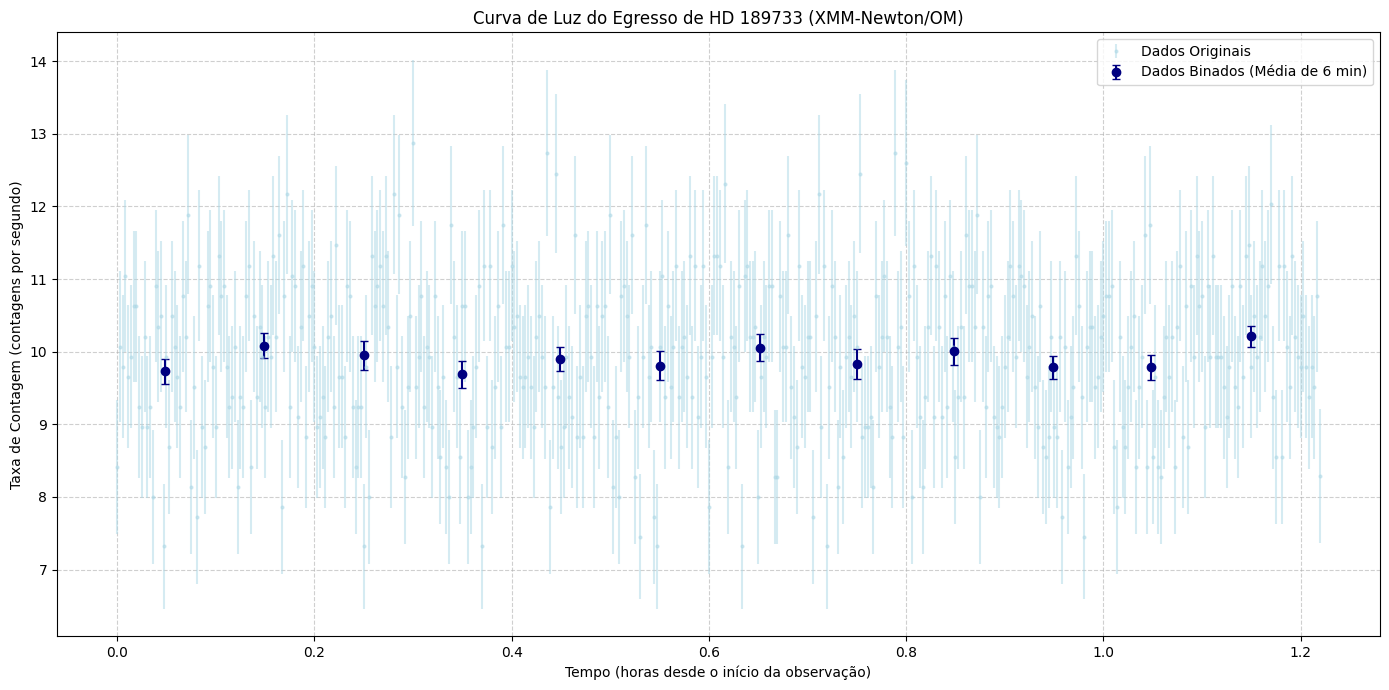

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- PASSO 1: CONFIGURAÇÃO ---
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE'
coluna_erro  = 'ERROR'

# --- PASSO 2: EXTRAIR OS DADOS (como antes) ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        dados_tabela = hdul[1].data
        tempos = dados_tabela[coluna_tempo]
        fluxos = dados_tabela[coluna_fluxo]
        erros_fluxo = dados_tabela[coluna_erro]
        print(f"Arquivo '{nome_arquivo_fits}' lido com sucesso!")
except Exception as e:
    print(f"Ocorreu um erro: {e}")
    exit()

# Converte o tempo para horas
tempos_em_horas = (tempos - tempos[0]) / 3600.0

# --- NOVO! PASSO 3: BINAR OS DADOS ---
# Vamos agrupar os dados em 'caixas' (bins) de 0.1 horas (6 minutos)
bin_size_horas = 0.1
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)

# Listas para guardar os dados binados
binned_time = []
binned_flux = []
binned_error = []

# Loop através de cada 'caixa' de tempo
for i in range(len(bins) - 1):
    # Encontra os pontos de dados que caem dentro desta 'caixa'
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    
    # Se houver pontos na 'caixa', calcula a média
    if np.sum(mask) > 0:
        # O tempo do bin é o centro da 'caixa'
        binned_time.append(np.mean(tempos_em_horas[mask]))
        # O fluxo do bin é a média dos fluxos
        binned_flux.append(np.mean(fluxos[mask]))
        # O erro do bin é o erro padrão da média
        n_points = len(fluxos[mask])
        binned_error.append(np.std(fluxos[mask]) / np.sqrt(n_points))

print(f"Dados binados em {len(binned_time)} pontos.")

# --- PASSO 4: PLOTAR TUDO ---
plt.figure(figsize=(14, 7))

# Plota os dados originais, mais fracos, como fundo
plt.errorbar(tempos_em_horas, fluxos, yerr=erros_fluxo, fmt='.', markersize=4, color='lightblue', ecolor='lightblue', capsize=0, alpha=0.5, label='Dados Originais')

# Plota os dados BINADOS, mais fortes, por cima
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=6, color='navy', ecolor='navy', capsize=3, label='Dados Binados (Média de 6 min)')

plt.title('Curva de Luz do Egresso de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Encontrados 10 arquivos de curva de luz do OM na pasta.
Processando arquivo: P0506070201OMS006TIMESR1001.FTZ
Processando arquivo: P0506070201OMS404TIMESR1001.FTZ
Processando arquivo: P0506070201OMS403TIMESR1001.FTZ
Processando arquivo: P0506070201OMS407TIMESR1001.FTZ
Processando arquivo: P0506070201OMS406TIMESR1001.FTZ
Processando arquivo: P0506070201OMS402TIMESR1001.FTZ
Processando arquivo: P0506070201OMS405TIMESR1001.FTZ
Processando arquivo: P0506070201OMS401TIMESR1001.FTZ
Processando arquivo: P0506070201OMS408TIMESR1001.FTZ
Processando arquivo: P0506070201OMS007TIMESR1001.FTZ

Processamento concluído. Total de 4400 pontos de dados combinados.


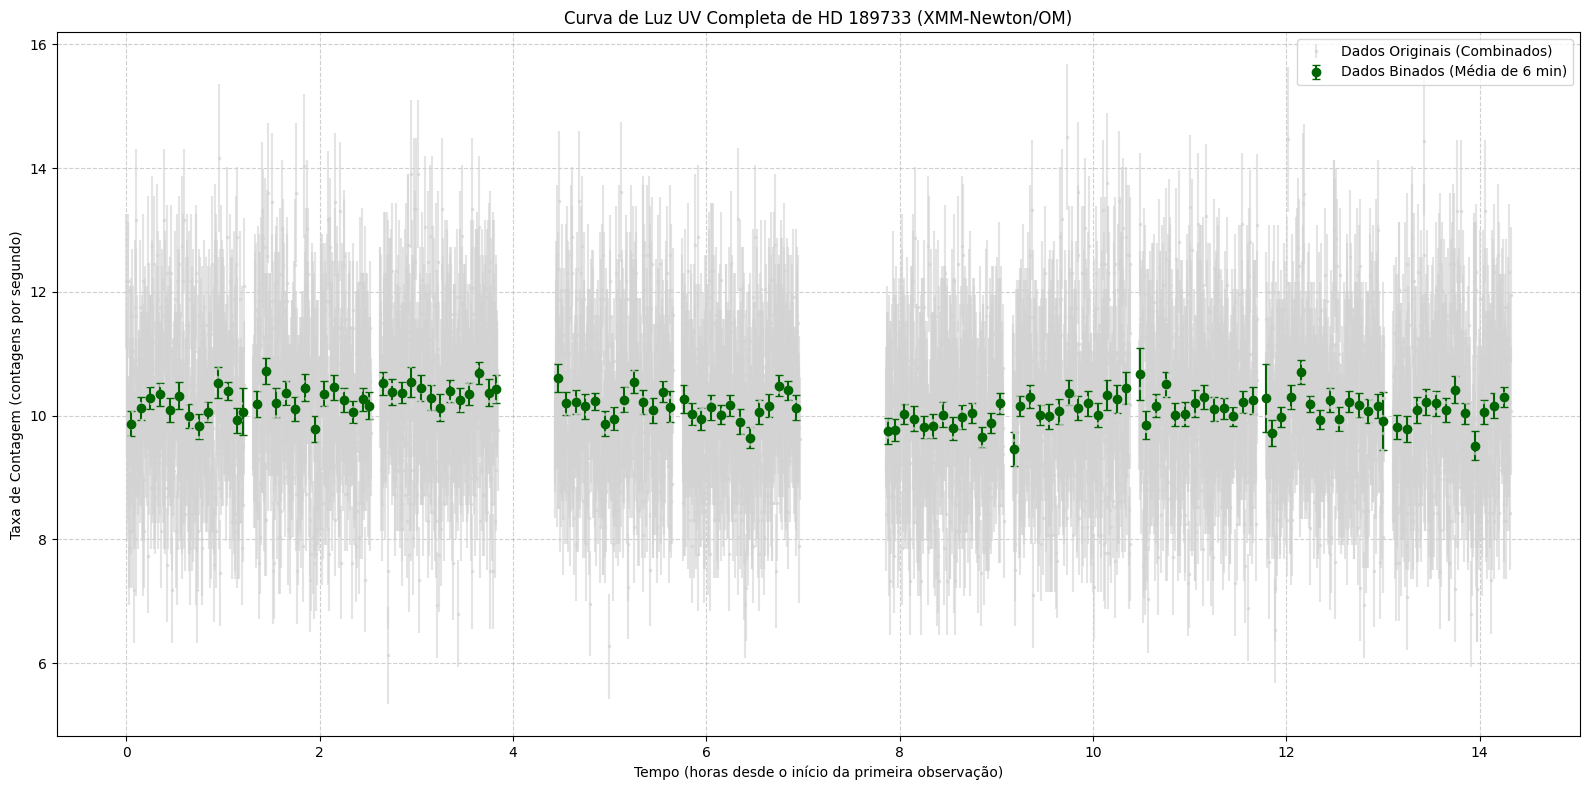

In [4]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- PASSO 1: CONFIGURAÇÃO ---
# !!! IMPORTANTE: EDITE ESTA LINHA COM O CAMINHO PARA A SUA PASTA !!!
# Exemplo no Windows: 'C:/Usuarios/Beatriz/Downloads/dados_xmm'
# Exemplo no Mac/Linux: '/Users/beatrizduque/Downloads/Mestrado/HD189733/dados'
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'

# Padrão para encontrar apenas os arquivos de curva de luz do Optical Monitor (OM)
padrao_arquivo = '*OM*TIMESR*.FTZ'

# Nomes das colunas
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE'
coluna_erro  = 'ERROR'

# --- PASSO 2: ENCONTRAR E PROCESSAR TODOS OS ARQUIVOS ---
# Cria o caminho completo para a busca
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)

# Listas para guardar todos os dados de todos os arquivos
todos_tempos = []
todos_fluxos = []
todos_erros = []

print(f"Encontrados {len(lista_arquivos)} arquivos de curva de luz do OM na pasta.")

# Loop para ler cada arquivo
for arquivo in lista_arquivos:
    try:
        print(f"Processando arquivo: {os.path.basename(arquivo)}")
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados[coluna_tempo])
            todos_fluxos.extend(dados[coluna_fluxo])
            todos_erros.extend(dados[coluna_erro])
    except Exception as e:
        print(f"  -> Erro ao processar o arquivo {os.path.basename(arquivo)}: {e}")

if not todos_tempos:
    print("\nNenhum dado foi extraído. Verifique o caminho da pasta e o padrão do arquivo.")
    exit()

# --- PASSO 3: JUNTAR, ORDENAR E BINAR OS DADOS ---
# Converter listas para arrays numpy
todos_tempos = np.array(todos_tempos)
todos_fluxos = np.array(todos_fluxos)
todos_erros = np.array(todos_erros)

# Ordenar todos os dados cronologicamente
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
erros_ordenados = todos_erros[indices_ordenados]

print(f"\nProcessamento concluído. Total de {len(tempos_ordenados)} pontos de dados combinados.")

# Converter tempo para horas desde o início da PRIMEIRA observação
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0

# Binning (exatamente como antes)
bin_size_horas = 0.1 # 6 minutos
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []

for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_ordenados[mask]))
        n_points = len(fluxos_ordenados[mask])
        binned_error.append(np.std(fluxos_ordenados[mask]) / np.sqrt(n_points))

# --- PASSO 4: PLOTAR A CURVA DE LUZ COMPLETA ---
plt.figure(figsize=(16, 8))

plt.errorbar(tempos_em_horas, fluxos_ordenados, yerr=erros_ordenados, fmt='.', markersize=3, color='lightgray', ecolor='lightgray', capsize=0, alpha=0.6, label='Dados Originais (Combinados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=6, color='darkgreen', ecolor='darkgreen', capsize=3, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')

plt.title('Curva de Luz UV Completa de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--------------------------------------------------
INICIANDO ANÁLISE DO TRÂNSITO
--------------------------------------------------
Fluxo médio fora do trânsito (linha de base): 10.1274 contagens/s
Fluxo normalizado estimado durante o trânsito: 0.9996
==> Profundidade do Trânsito estimada: 0.0004 ou 0.04%

Raio da estrela (Rs): 522,255 km
==> Raio do Planeta (Rp) estimado: 10,711 km
==> Isso equivale a aproximadamente 0.15 vezes o raio de Júpiter.
--------------------------------------------------


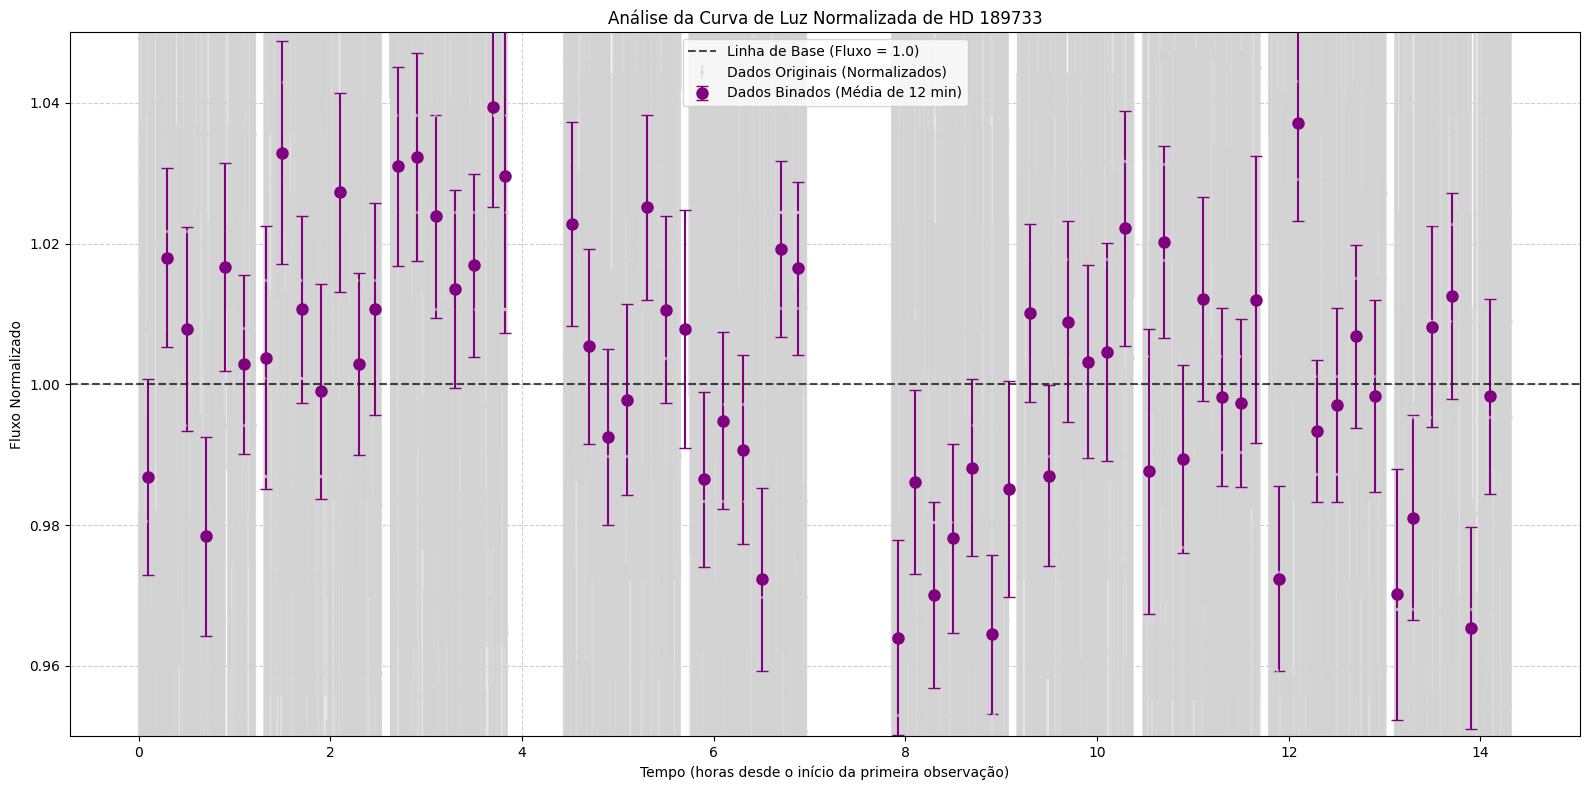

In [1]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E EXTRAÇÃO DE DADOS (Como no script anterior) ---
# !!! EDITE ESTA LINHA COM O CAMINHO PARA A SUA PASTA !!!
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
padrao_arquivo = '*OM*TIMESR*.FTZ'
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)

todos_tempos, todos_fluxos, todos_erros = [], [], []
for arquivo in lista_arquivos:
    with fits.open(arquivo) as hdul:
        dados = hdul[1].data
        todos_tempos.extend(dados['TIME'])
        todos_fluxos.extend(dados['RATE'])
        todos_erros.extend(dados['ERROR'])

todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0

# --- 2. ANÁLISE DO TRÂNSITO ---
print("-" * 50)
print("INICIANDO ANÁLISE DO TRÂNSITO")
print("-" * 50)

# Passo 1: Calcular o fluxo fora de trânsito e normalizar
mask_fora_transito = tempos_em_horas > 3.0
fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
print(f"Fluxo médio fora do trânsito (linha de base): {fluxo_fora_transito:.4f} contagens/s")

# Normaliza todos os dados
fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
erros_normalizados = todos_erros[indices_ordenados] / fluxo_fora_transito

# Passo 2: Estimar a profundidade do trânsito
# Usaremos a média dos primeiros 20 minutos (1/3 de hora) para estimar o fluxo em trânsito
mask_em_transito = tempos_em_horas < (1/3)
fluxo_em_transito_norm = np.mean(fluxos_normalizados[mask_em_transito])
print(f"Fluxo normalizado estimado durante o trânsito: {fluxo_em_transito_norm:.4f}")

# A profundidade é 1 menos o fluxo normalizado em trânsito
profundidade = 1.0 - fluxo_em_transito_norm
print(f"==> Profundidade do Trânsito estimada: {profundidade:.4f} ou {profundidade*100:.2f}%")

# Passo 3: Calcular o raio do planeta
# Constantes
raio_estrela_em_raios_solares = 0.75
raio_sol_km = 696340
raio_jupiter_km = 69911

# Cálculo
raio_estrela_km = raio_estrela_em_raios_solares * raio_sol_km
raio_planeta_km = raio_estrela_km * np.sqrt(profundidade)
raio_planeta_em_raios_jupiter = raio_planeta_km / raio_jupiter_km

print(f"\nRaio da estrela (Rs): {raio_estrela_km:,.0f} km")
print(f"==> Raio do Planeta (Rp) estimado: {raio_planeta_km:,.0f} km")
print(f"==> Isso equivale a aproximadamente {raio_planeta_em_raios_jupiter:.2f} vezes o raio de Júpiter.")
print("-" * 50)

# --- 3. PLOTAR A CURVA DE LUZ NORMALIZADA ---
# Binning dos dados normalizados
bin_size_horas = 0.2
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_normalizados[mask]))
        n_points = len(fluxos_normalizados[mask])
        binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

plt.figure(figsize=(16, 8))
plt.errorbar(tempos_em_horas, fluxos_normalizados, yerr=erros_normalizados, fmt='.', markersize=3, color='lightgray', alpha=0.5, label='Dados Originais (Normalizados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base (Fluxo = 1.0)')

plt.title('Análise da Curva de Luz Normalizada de HD 189733')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Fluxo Normalizado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# Ajusta o eixo Y para melhor visualização da profundidade
plt.ylim(0.95, 1.05)
plt.tight_layout()
plt.show()

--------------------------------------------------
JANELA DO TRÂNSITO (MEDIDA A PARTIR DOS DADOS)
Fim do egresso observado em: ~2.50 h
Início do trânsito inferido em: ~0.70 h
--------------------------------------------------


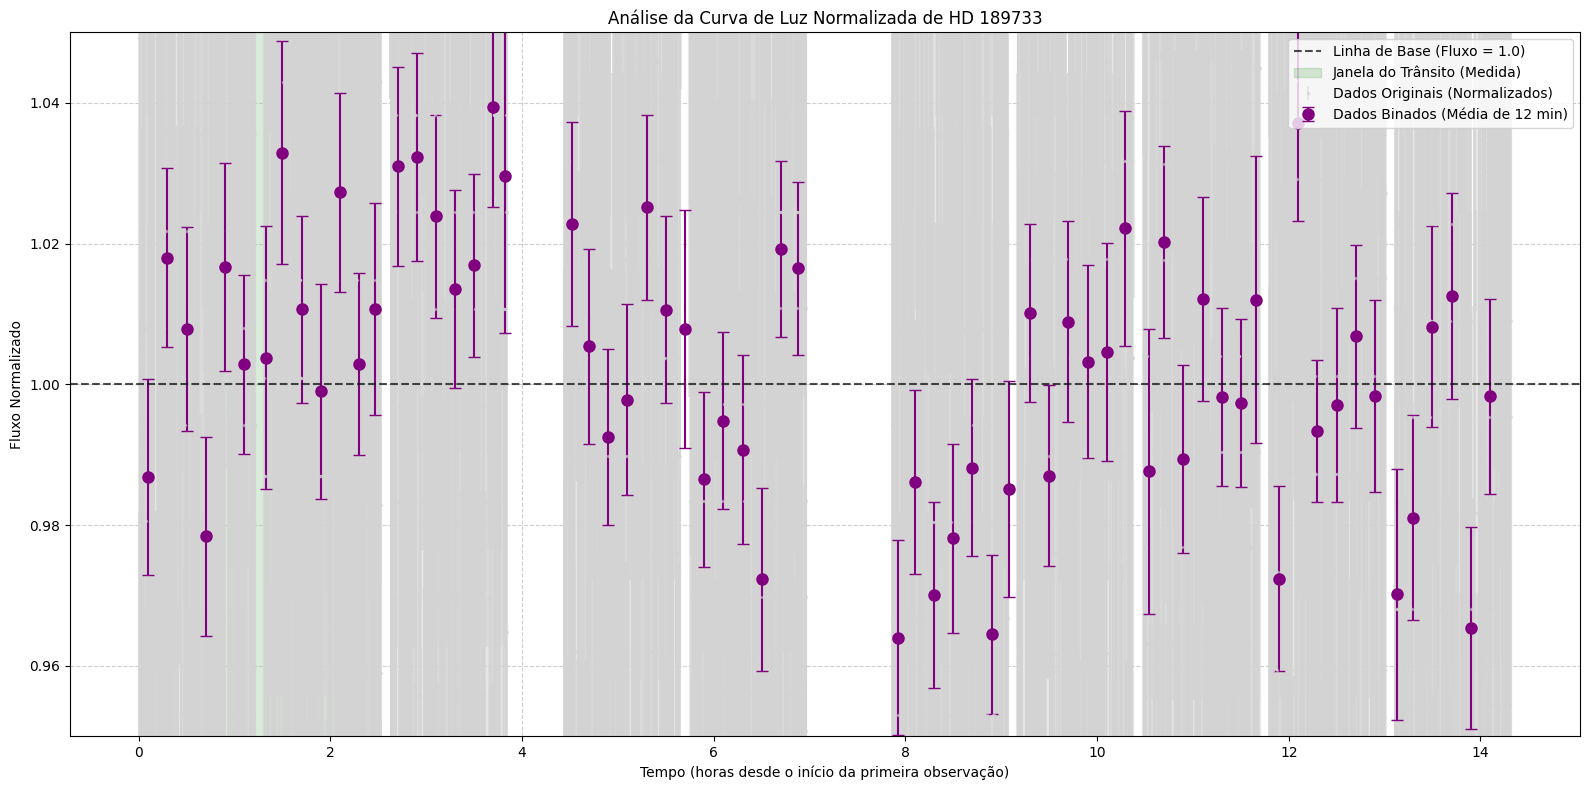

In [2]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E EXTRAÇÃO DE DADOS (Sem alterações) ---
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
padrao_arquivo = '*OM*TIMESR*.FTZ'
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)
todos_tempos, todos_fluxos, todos_erros = [], [], []
for arquivo in lista_arquivos:
    with fits.open(arquivo) as hdul:
        dados = hdul[1].data
        todos_tempos.extend(dados['TIME'])
        todos_fluxos.extend(dados['RATE'])
        todos_erros.extend(dados['ERROR'])
todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
erros_ordenados = todos_erros[indices_ordenados]
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
fluxos_normalizados = fluxos_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])
erros_normalizados = erros_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])

# --- NOVO! CÁLCULO DA JANELA DO TRÂNSITO (BASEADO NOS DADOS OBSERVADOS) ---
# Pela inspeção visual do nosso gráfico, o egresso termina por volta de 2.5 horas.
fim_transito_horas = 2.5  # [horas] - O ponto onde a curva se torna plana
duracao_transito_horas = 1.8 # [horas] - A duração conhecida do evento
inicio_transito_horas = fim_transito_horas - duracao_transito_horas

print("-" * 50)
print("JANELA DO TRÂNSITO (MEDIDA A PARTIR DOS DADOS)")
print(f"Fim do egresso observado em: ~{fim_transito_horas:.2f} h")
print(f"Início do trânsito inferido em: ~{inicio_transito_horas:.2f} h")
print("-" * 50)


# --- 3. PLOTAGEM (Sem alterações, mas agora usará os valores corretos) ---
# Binning
bin_size_horas = 0.2
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_normalizados[mask]))
        n_points = len(fluxos_normalizados[mask])
        binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

plt.figure(figsize=(16, 8))
plt.errorbar(tempos_em_horas, fluxos_normalizados, yerr=erros_normalizados, fmt='.', markersize=3, color='lightgray', alpha=0.5, label='Dados Originais (Normalizados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base (Fluxo = 1.0)')

# axvspan agora usará os valores medidos dos dados
plt.axvspan(inicio_transito_horas, fim_transito_horas, color='green', alpha=0.15, label='Janela do Trânsito (Medida)')

plt.title('Análise da Curva de Luz Normalizada de HD 189733')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Fluxo Normalizado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.95, 1.05)
plt.tight_layout()
plt.show()

# Curva de luz vs Modelo

### Artigo
[Link para o artigo](https://watermark02.silverchair.com/stab1863.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA1kwggNVBgkqhkiG9w0BBwagggNGMIIDQgIBADCCAzsGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMf9_JjMB4oH09J9C1AgEQgIIDDBH3Bera5fpzs0PolLIh7xo-JqoMyWHA0qdHqrozioJ-H2AD1ZA4vHzcBc-C8GQbt57Lsd6sMfY7Jyp0ccjpuuJ-IpBd8GPjQ_I0fW9wuIYBT5SPN88Xc2OOEFRZjrDerU_kPNB43U17JEZz62ay9KZVG3q05SQicHGg78A2qpuguY7Bm03xG5TT0x24uQYQUtMAcqSoU1xyFpLoSr463kPQ5Y8GWr_Khl0IqvDgH9cUcgt3gjsStBFqrBMTtWdcluz-yjycbVDPHTJKV0o_QdeJg4rMGXqvzMijbDdt4IRArpi7U3qNuUDt02A6DFnmGs4VQBm3-z_2qMH9TmVzdSX73XqH3LM70K5hUu66DVI5JtgYrf_5upXfxnDF0uvhOGjoOxuLZt6rLgOgjSYXvB_WzmVKdtmx6YDBlgdGTFgvvQk2aJUJ4G10nF1k6XYxjrmhJ2XrKDDAZR1XQKj5qLC_nCBeyKoCwyRvZL_HYV6FmbGso_UEy1wvU3IIKt4tdu5ATL5OuGEfzBLbWfY64kfGKrwdYDxcOhcqbYexsuBfh-KcV7Tggs0oCRe38oXbW4gVZoc5vew0WsBTm9GZFvHHLU5iczMlH8sLzW7WhtC-5KF0b8ERBGG3mOXwVW4bGFSlh1FDOQ0a9mCB91nifXEsU1zkNY6n8C-NnJRO1DTbH9Zf3763C-2laV18hClF4djnX9fT9EHE4CxirnRGCtZ466btkEW5Y0B8Fn5wC-Pgn-BX86JK8O7h7zWPsoWfg8fllwnv4wwASQ-i2YcwoozQciFLl9djDWMnvFgpvzm0VC86IEWbTuK5q5VBMznU9KNo9sMfb4SwiH4h_pU86Dlf2M8aFIl4B6io8WEyrWFVZx3BRhlHnzDy7aXZrvmejF_AEA8VMlo82CgUl4MCm85i0yZ_UzdFVQotht-1XPRM3a3r7DrRwwfmZPoKpBkUu8Sxrdy8uWpieaYNybaV0VxKoMd8G7unB7h5SgHDq8R6Ug8s3RSU7BZ0fEDLu6oD6sW0j26IH5MtK2eUnw)

# Metodologia de Cálculo de Efemérides de Trânsito

Este documento descreve o método utilizado para prever os tempos de trânsito do exoplaneta HD 189733b para uma data de observação específica. O processo utiliza uma efeméride de alta precisão para garantir a acurácia dos resultados ao longo de longos períodos.

### 1. Parâmetros de Entrada

O cálculo se baseia em uma efeméride de alta precisão para o sistema HD 189733b, compilada a partir de dados da literatura (e.g., Agol et al. 2010) e disponibilizada pelo NASA Exoplanet Archive.

* **Época de Referência (T₀):**
    * **Valor:** `2454279.436593`
    * **Unidade:** BJD_TDB (Data Juliana Baricêntrica, no padrão de Tempo Dinâmico Baricêntrico).
    * **Descrição:** O tempo exato do meio de um trânsito de referência bem estabelecido.

* **Período Orbital (P):**
    * **Valor:** `2.21857520`
    * **Unidade:** Dias.
    * **Descrição:** O tempo exato que o planeta leva para completar uma órbita.

* **Duração do Trânsito (D):**
    * **Valor:** `1.8`
    * **Unidade:** Horas.
    * **Descrição:** A duração total do evento, do primeiro ao último contato.

### 2. Processo de Cálculo

Para uma dada data de interesse (ex: `2014-11-15`), o tempo do meio do trânsito ($T_C$) é calculado em quatro etapas:

1.  **Conversão de Tempo:** A data de interesse é convertida para o formato de Data Juliana (JD), que é um sistema contínuo de contagem de dias, ideal para cálculos astronômicos.

2.  **Cálculo do Número da Órbita (n):** O número de órbitas completas entre a época de referência ($T_0$) e a data de interesse é determinado. A fórmula utilizada arredonda para o número inteiro mais próximo, garantindo que encontremos o trânsito mais próximo da data especificada.
    $$
    n = \text{round}\left( \frac{\text{JD}_{\text{data de interesse}} - T_0}{P} \right)
    $$

3.  **Cálculo do Tempo do Meio do Trânsito:** Com o número da órbita `n`, o tempo exato do meio do trânsito ($T_C$) é calculado em Data Juliana, propagando a efeméride a partir da época de referência.
    $$
    T_C(\text{JD}) = T_0 + (n \times P)
    $$

4.  **Conversão para UTC:** O resultado final em Data Juliana é convertido de volta para o formato de data e hora padrão (AAAA-MM-DD HH:MM:SS UTC) para fácil interpretação.

### 3. Saídas

O processo resulta nos seguintes tempos:

* **Meio do Trânsito:** O horário exato (UTC) do centro do evento.
* **Início do Trânsito:** O horário do Meio do Trânsito subtraído de metade da duração total (`D / 2`).
* **Fim do Trânsito:** O horário do Meio do Trânsito somado a metade da duração total (`D / 2`).

### 4. Exemplo de Implementação em Python

A função abaixo encapsula a metodologia descrita, utilizando a biblioteca `Astropy` para um tratamento de tempo robusto e preciso.


In [28]:
from astropy.time import Time
from astropy.time import TimeDelta
import numpy as np

def calcular_transito(data_alvo_str, T0=2454279.436593, P=2.21857520, duracao_horas=1.8):
    """
    Calcula os tempos de início, meio и fim de um trânsito de HD 189733b
    próximo a uma data alvo, usando uma efeméride de alta precisão.

    Args:
        data_alvo_str (str): A data de interesse no formato 'AAAA-MM-DD HH:MM:SS'.
        T0 (float): A época de referência em JD.
        P (float): O período orbital em dias.
        duracao_horas (float): A duração total do trânsito em horas.

    Returns:
        dict: Um dicionário contendo os tempos do trânsito em formato JD e UTC.
    """
    # Converter a data de interesse para o objeto Time do Astropy
    t_alvo = Time(data_alvo_str, format='iso', scale='utc')
    
    # Calcular o número da órbita
    n_orbita = np.round((t_alvo.jd - T0) / P)
    
    # Calcular o tempo do meio do trânsito em JD
    jd_meio_transito = T0 + (n_orbita * P)
    
    # Converter o resultado JD para um objeto Time
    t_meio_transito = Time(jd_meio_transito, format='jd', scale='tdb')
    
    # --- CORREÇÃO APLICADA AQUI ---
    # Calcular início e fim do trânsito
    # Converte a duração de horas para segundos (1 hora = 3600s) e usa o formato 'sec'
    metade_duracao_segundos = (duracao_horas / 2.0) * 3600.0
    metade_duracao = TimeDelta(metade_duracao_segundos, format='sec')
    
    t_inicio_transito = t_meio_transito - metade_duracao
    t_fim_transito = t_meio_transito + metade_duracao
    
    # Preparar o dicionário de resultados
    resultados = {
        'orbita_n': int(n_orbita),
        'meio_transito_utc': t_meio_transito.utc.iso,
        'inicio_transito_utc': t_inicio_transito.utc.iso,
        'fim_transito_utc': t_fim_transito.utc.iso,
        'meio_transito_jd': jd_meio_transito
    }
    
    return resultados

# --- Exemplo de Uso ---
data_teste = '2014-11-15 12:00:00'
T0 = 2454279.436593
P = 2.21857520
duracao_horas = 1.8 # (e.g., Torres et al. 2008)
transito_previsto = calcular_transito(data_teste, T0, P, duracao_horas)
print(transito_previsto)

{'orbita_n': 1216, 'meio_transito_utc': '2014-11-15 17:21:29.545', 'inicio_transito_utc': '2014-11-15 16:27:29.545', 'fim_transito_utc': '2014-11-15 18:15:29.545', 'meio_transito_jd': 2456977.2240362}


In [1]:
from Star.Estrela import Estrela
from Planet.Eclipse import Eclipse
from Planet.Planeta import Planeta
import matplotlib.pyplot as plt
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

https://exoplanetarchive.ipac.caltech.edu/overview/hd%20189733

Parâmetros de Alta Precisão:
Época (T₀): 2454279.436593 BJD_TDB

Período (P): 2.21857520 dias

### Funções base

In [2]:
def modelo_de_transito_eclipse(tempo_horas_alvo, parametros):
    """
    Esta função usa o código ECLIPSE para gerar um modelo de trânsito.
    """
    
    # --------------------- Estrela ---------------------
    raio = 373.
    intensidadeMaxima = 240
    tamanhoMatriz = 856
    u1 = parametros['u1']
    u2 = parametros['u2']

    # --------------------- Planeta ---------------------
    raio_plan_Jup = parametros['raio_plan_Jup']
    semi_eixo_UA = parametros['semi_eixo_UA']
    angulo_inclinacao = parametros['angulo_inclinacao']
    periodo = parametros['periodo']
    mass_planeta = 1.138
    ecc = 0
    anomalia = 0
    rsun = parametros['rsun']
    
    estrela_ = Estrela(raio, rsun, intensidadeMaxima, u1, u2, tamanhoMatriz)
    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_ = Planeta(semi_eixo_UA, raio_plan_Jup, periodo, angulo_inclinacao, ecc, anomalia, estrela_.getRaioSun(), mass_planeta)

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_,1)
    
    # Define a duração total da simulação para garantir que o trânsito completo seja gerado
    # Por exemplo, 5 horas é suficiente para um trânsito de 1.8h
    eclipse.setTempoHoras(5.) 

    eclipse.criarEclipse(anim=False, plot=False) # plot=False para não gerar gráficos intermediários
    
    lc0 = np.array(eclipse.getCurvaLuz()) 
    ts0 = np.array(eclipse.getTempoHoras())

    # --- ETAPA DE ALINHAMENTO E INTERPOLAÇÃO ---
    # 1. Normalizar o modelo Eclipse (caso ele não esteja entre 0 e 1)
    lc0_normalizado = lc0 / np.max(lc0)
    
    # 2. Encontrar o tempo do centro do trânsito no modelo
    tempo_centro_modelo_simulado = ts0[np.argmin(lc0_normalizado)]

    # 3. Deslocar o eixo de tempo do modelo para que o centro do trânsito
    #    se alinhe com o centro que medimos nos dados observados (t0)
    ts0_alinhado = ts0 - tempo_centro_modelo_simulado + parametros['t0']

    # 4. Interpolar o modelo para os pontos de tempo do nosso gráfico final
    #    Isso cria a linha suave e contínua
    fluxo_final_modelo = np.interp(tempo_horas_alvo, ts0_alinhado, lc0_normalizado)
    
    return fluxo_final_modelo

def busca_fluxo_normalizado(lista_arquivos): 
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    fluxos_normalizados = fluxos_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])
    return tempos_em_horas, fluxos_normalizados


def bin_data(tempos_em_horas, fluxos_normalizados, bin = 0.2): 
    bin_size_horas = bin
    bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
    binned_time, binned_flux, binned_error = [], [], []

    for i in range(len(bins) - 1):
        mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
        if np.sum(mask) > 0:
            binned_time.append(np.mean(tempos_em_horas[mask]))
            binned_flux.append(np.mean(fluxos_normalizados[mask]))
            n_points = len(fluxos_normalizados[mask])
            binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

    
    return binned_time, binned_flux, binned_error


In [3]:
def plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs): 
    plt.figure(figsize=(16, 8))
    plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Observados (Binados)')
    plt.plot(tempo_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, label='Modelo ECLIPSE')
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base')
    plt.title('Modelo de Trânsito para HD 189733 vs Dados Observados: ' + date_obs + " ID:" + id_obs)
    plt.xlabel('Tempo (horas desde o início da primeira observação)')
    plt.ylabel('Fluxo Normalizado')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0.95, 1.05)
    plt.tight_layout()
    plt.show()

In [4]:
padrao_arquivo = '*OM*TIMESR*.FTZ'

### Definição dos parâmetros para execução do modelo

In [5]:
parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.0618,
    'u2': 0.0204,
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031,
    'angulo_inclinacao': 85.710,
    'periodo': 2.21857520,
    # Parâmetro medido dos dados para alinhamento
    't0': 1 # Centro do trânsito default
}

# 1) 2007-04-17 14:06:31 a 2007-04-18 05:20:49
0506070201

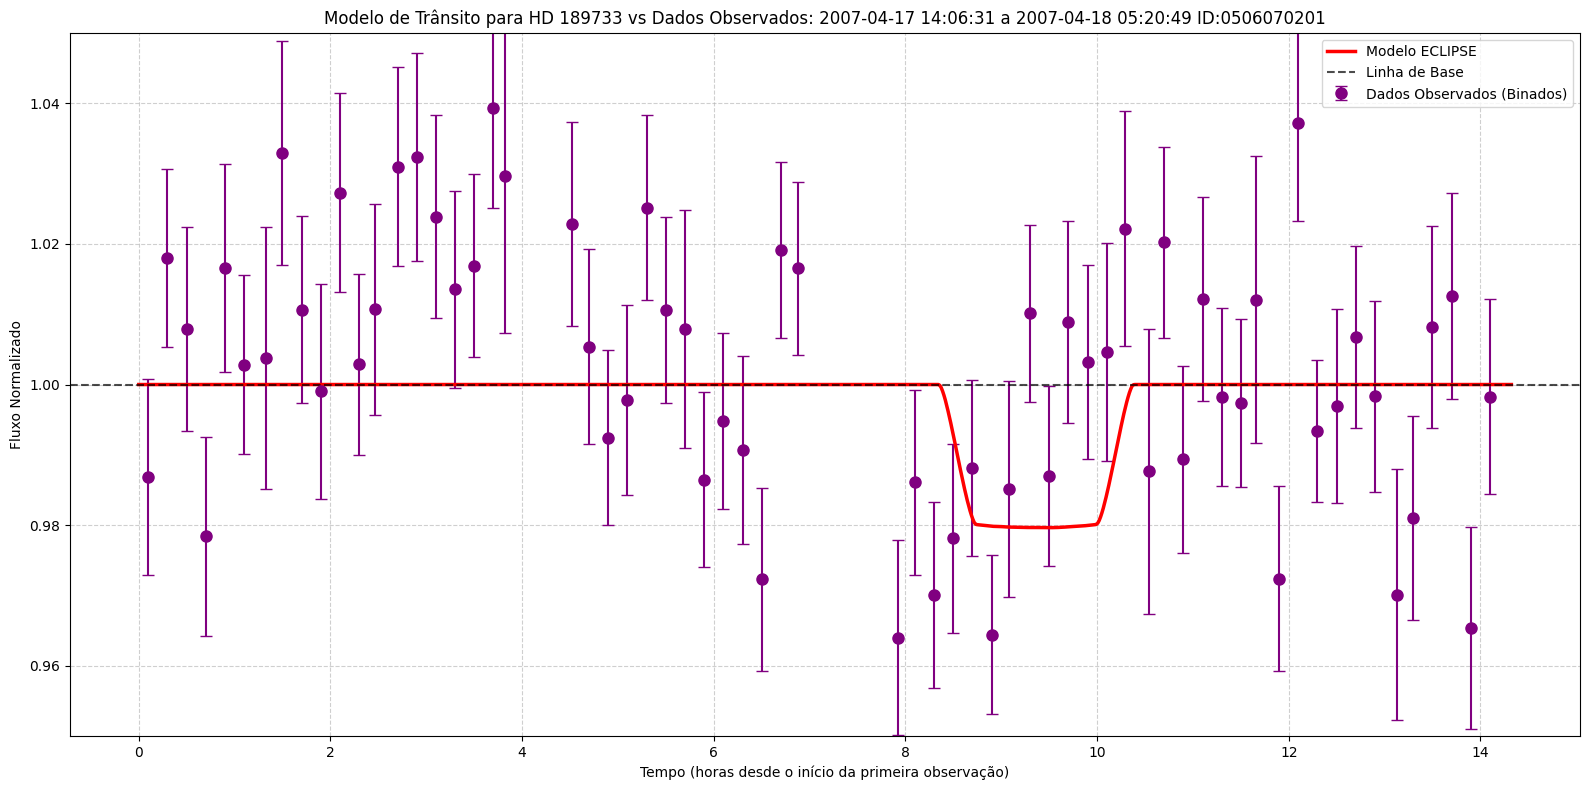

In [146]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2007-04-17 14:06:31 a 2007-04-18 05:20:49"
id_obs = "0506070201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
parametros_modelo['t0']= 9.5161 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 2) 2012-06-07 18:24:32 a 2012-06-08 11:29:48
0690890201

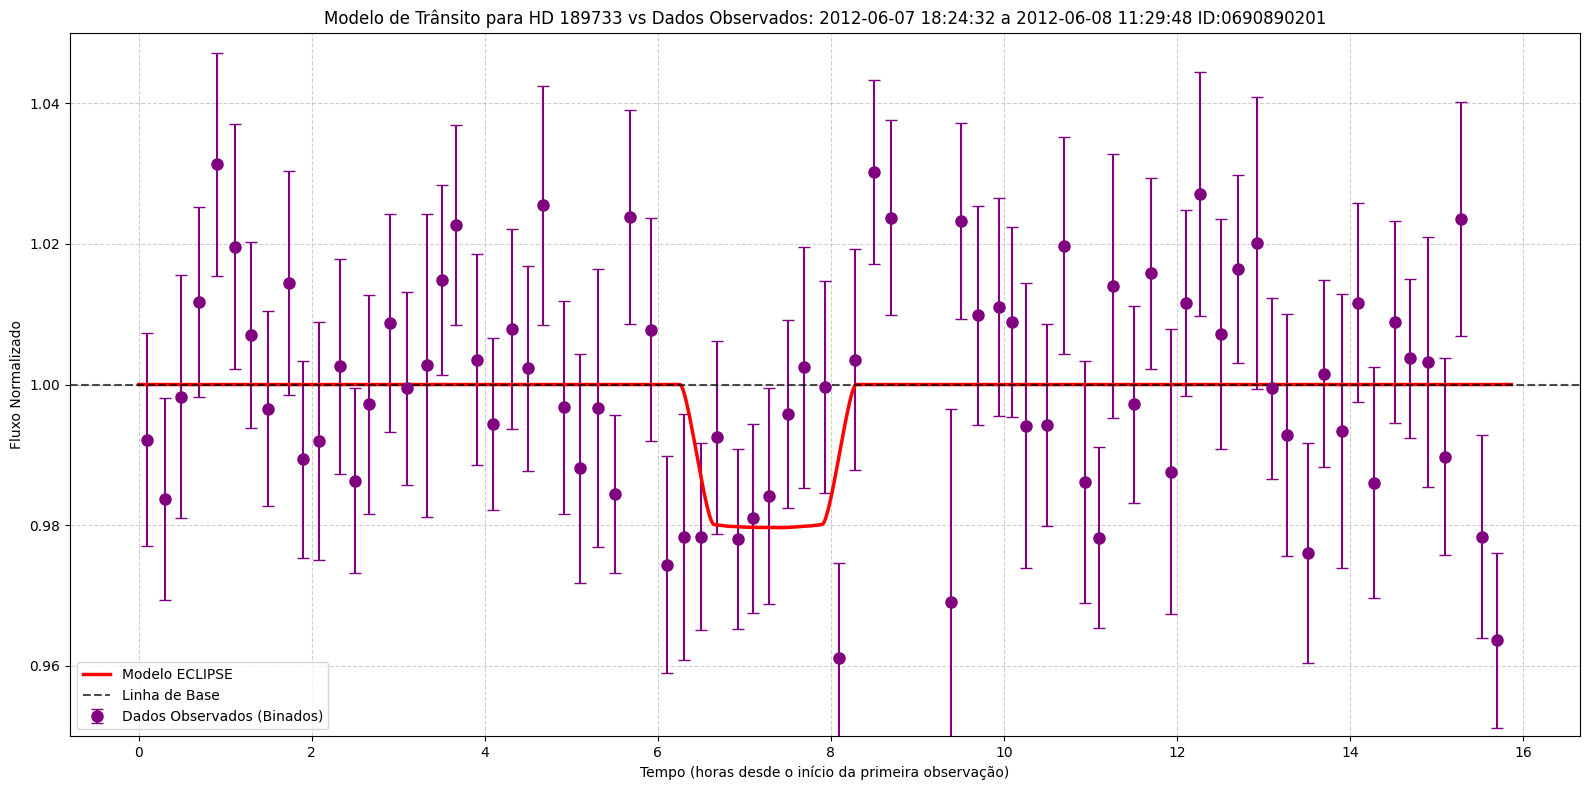

In [147]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2012-06-07 18:24:32 a 2012-06-08 11:29:48"
id_obs = "0690890201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/'
parametros_modelo['t0']= 7.4245 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 3) 2011-04-30 23:14:20 a 2011-05-01 10:06:12
0672390201

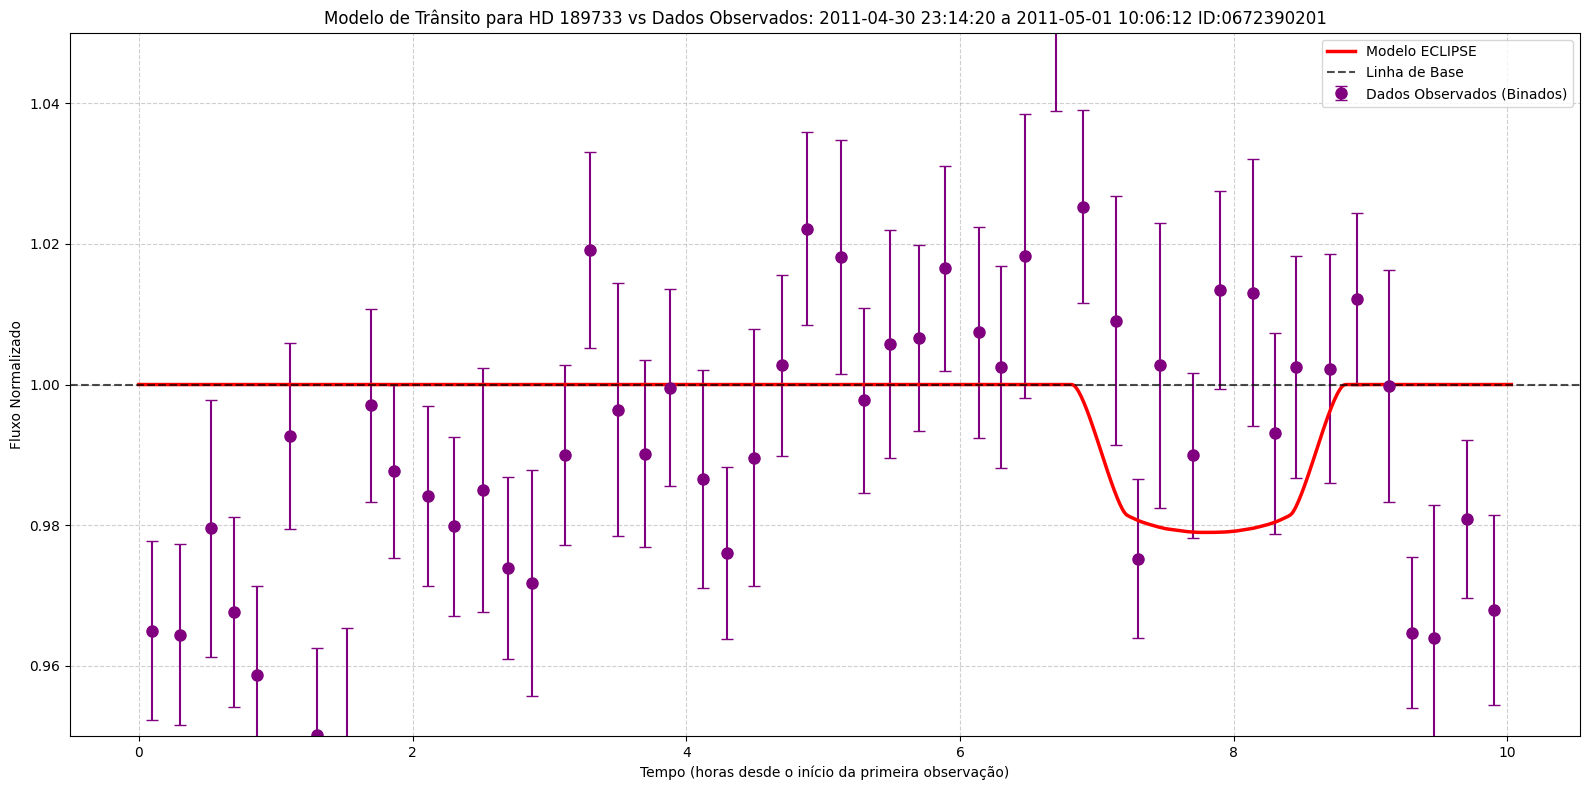

In [289]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2011-04-30 23:14:20 a 2011-05-01 10:06:12"
id_obs = "0672390201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/'
parametros_modelo['t0']= 7.8336 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados,0.2)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 4) 2014-11-13 06:46:05 a 2014-11-13 15:39:25
0744981401

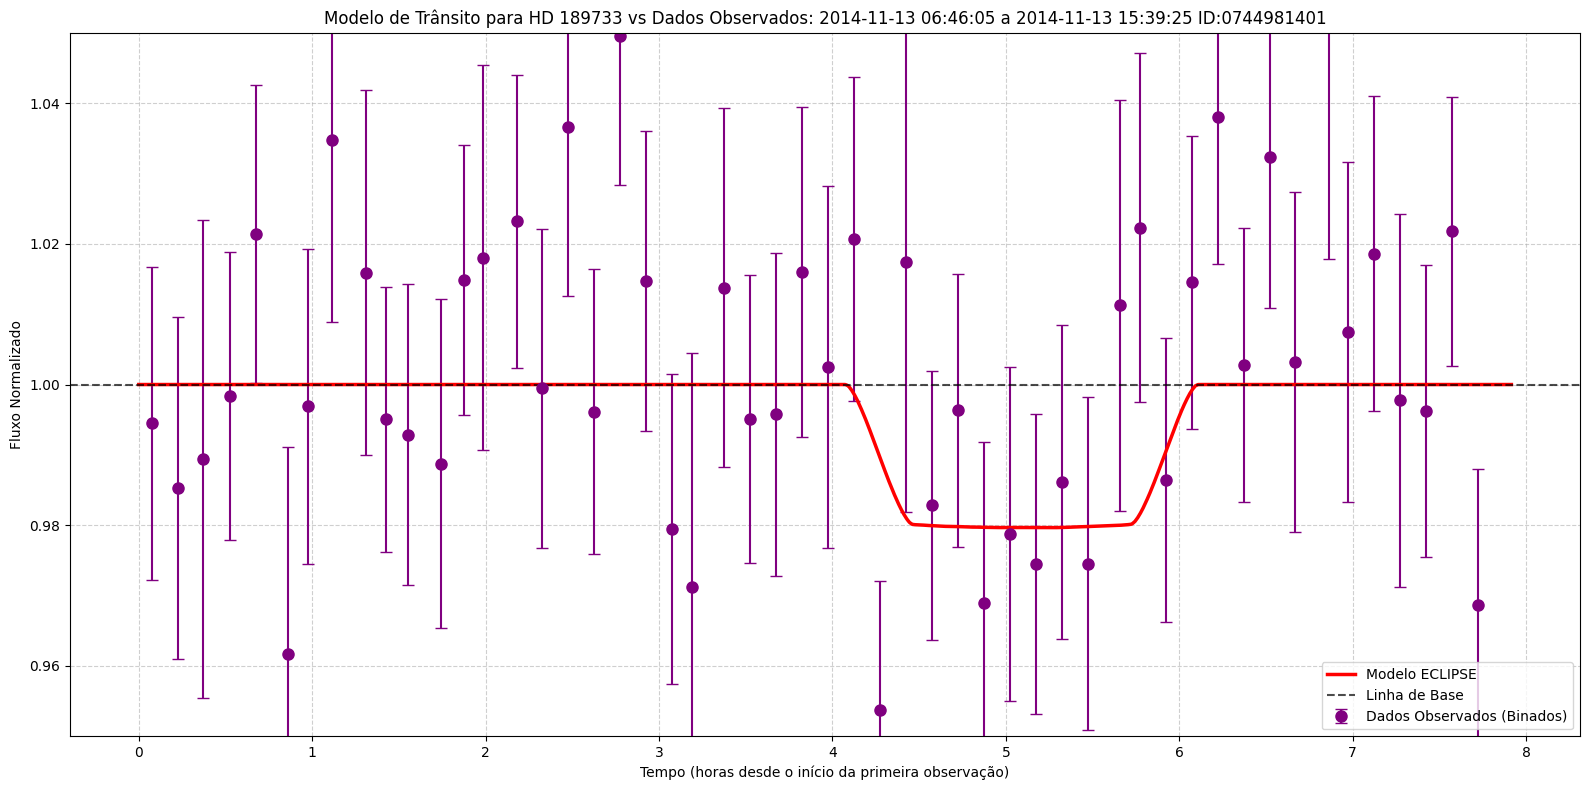

In [153]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2014-11-13 06:46:05 a 2014-11-13 15:39:25"
id_obs = "0744981401"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/'
parametros_modelo['t0']= 5.2427 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 5) 2015-04-17 12:34:55 a 2015-04-17 23:58:15
0744981601

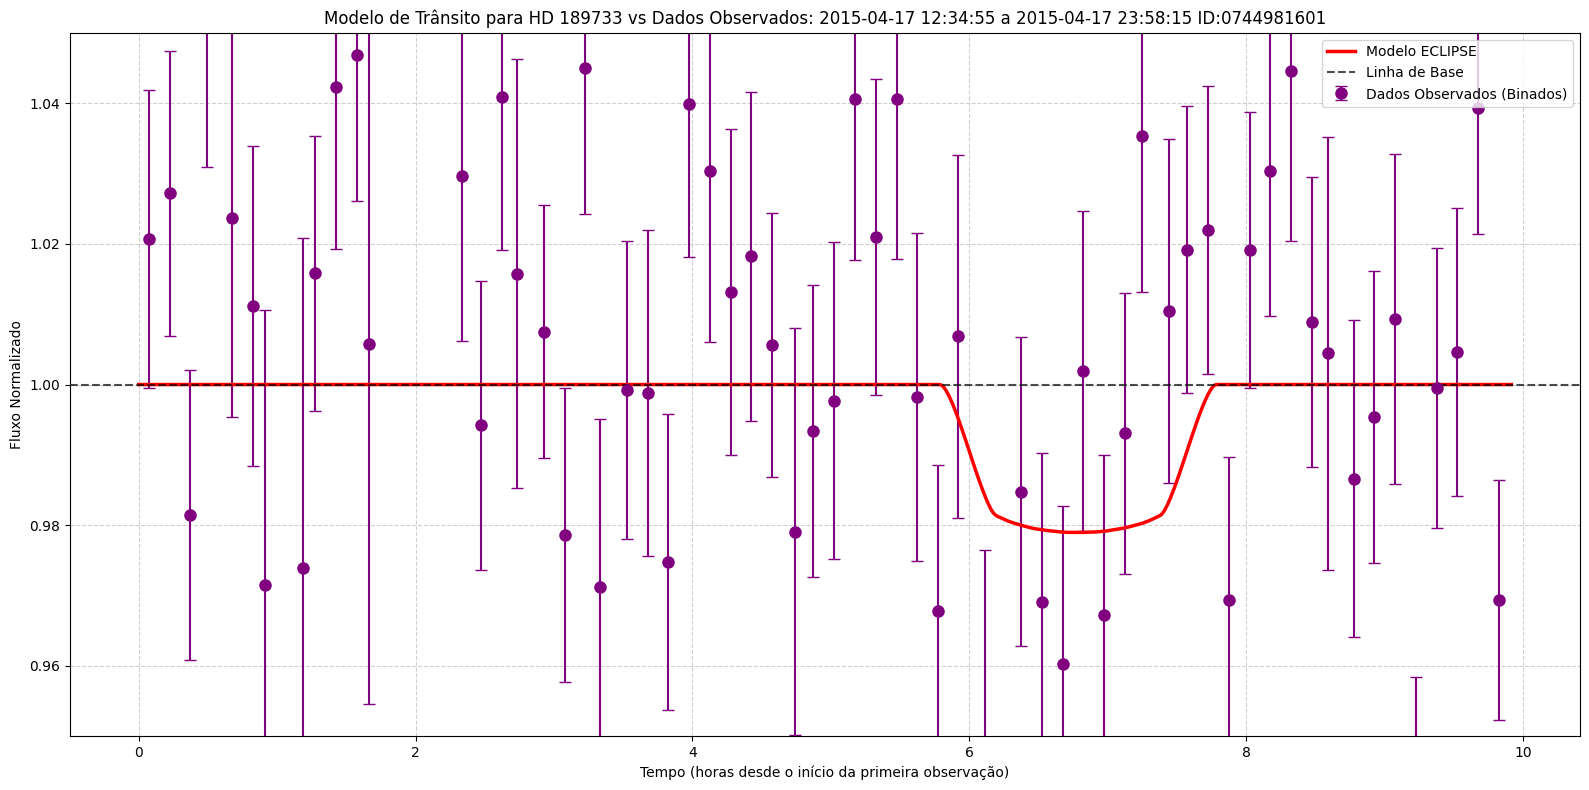

In [251]:
date_obs = "2015-04-17 12:34:55 a 2015-04-17 23:58:15"
id_obs = "0744981601"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981601/pps/'
parametros_modelo['t0']= 6.8033 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 6) 2015-04-19 19:06:26 a 2015-04-20 05:39:46
0744981701

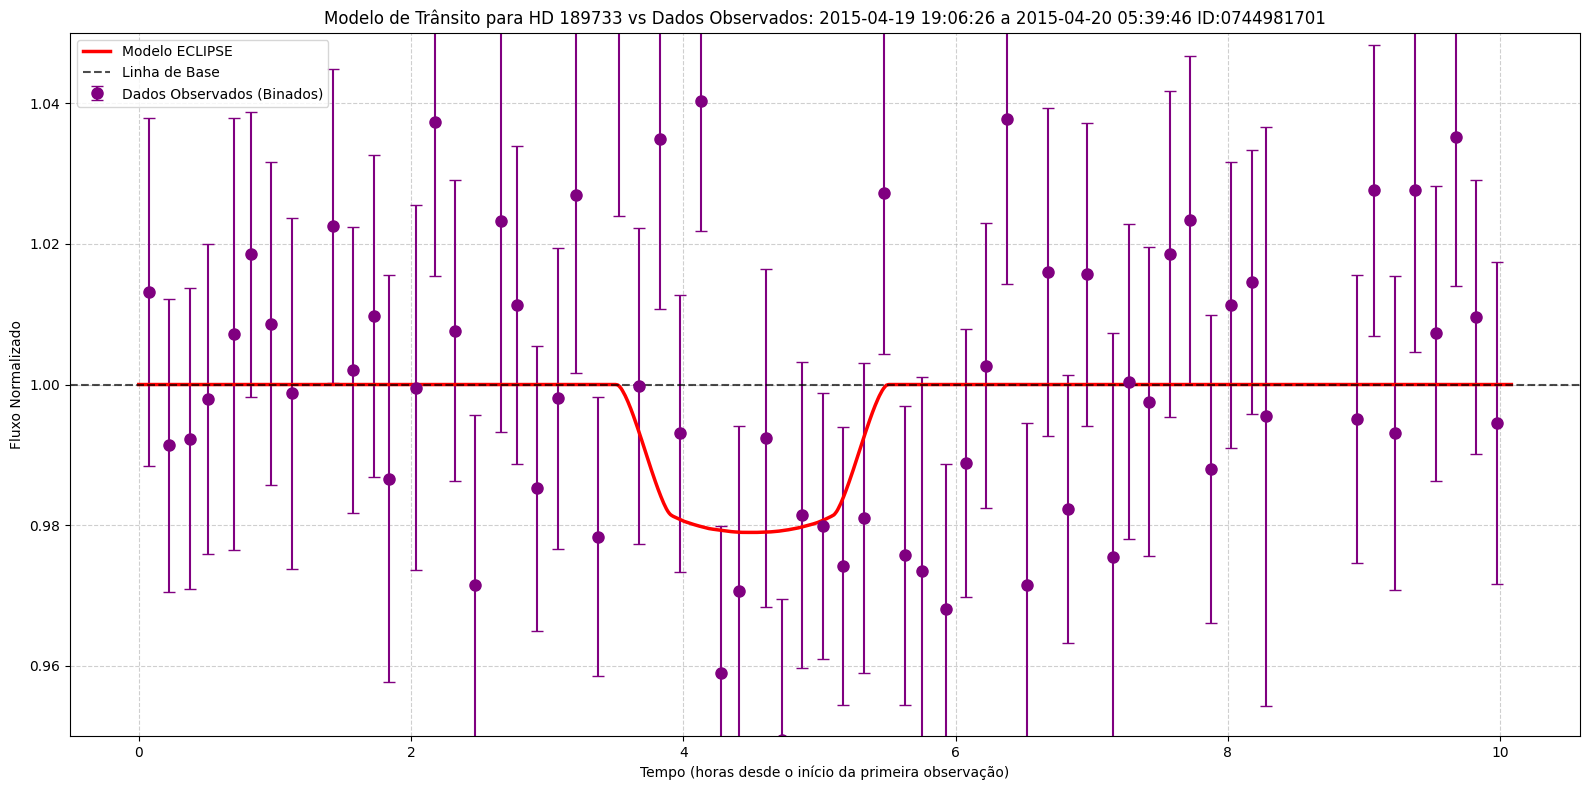

In [252]:
date_obs = "2015-04-19 19:06:26 a 2015-04-20 05:39:46"
id_obs = "0744981701"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981701/pps/'
parametros_modelo['t0']= 4.5239 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 7) 2014-10-17 16:08:26 a 2014-10-18 02:25:06
0744980801

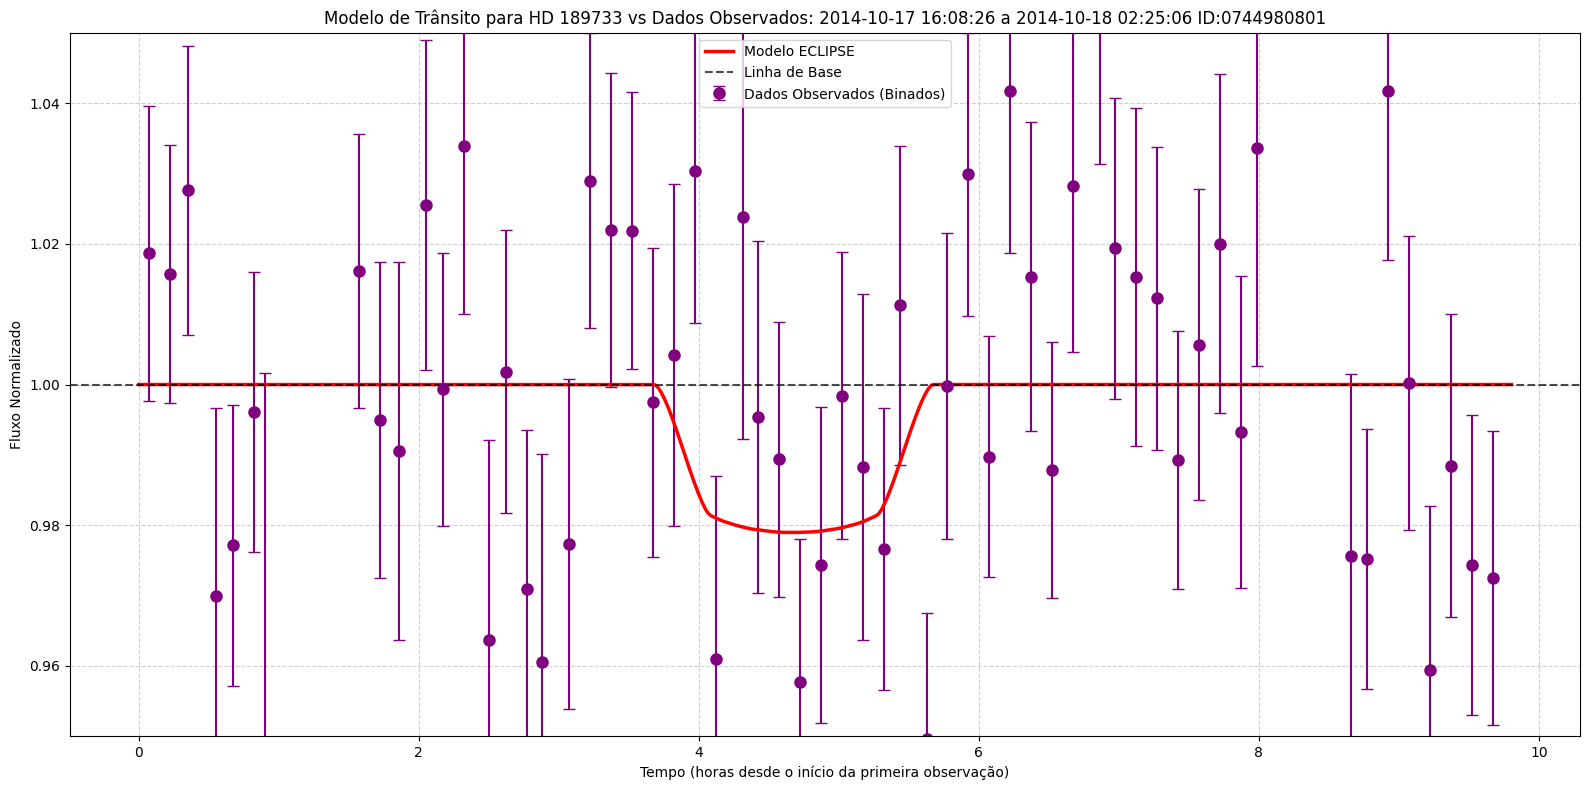

In [260]:
date_obs = "2014-10-17 16:08:26 a 2014-10-18 02:25:06"
id_obs = "0744980801"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980801/pps/'
parametros_modelo['t0']= 4.695 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 8) 2014-05-17 14:21:12 a 2014-05-17 23:14:32
0744980601

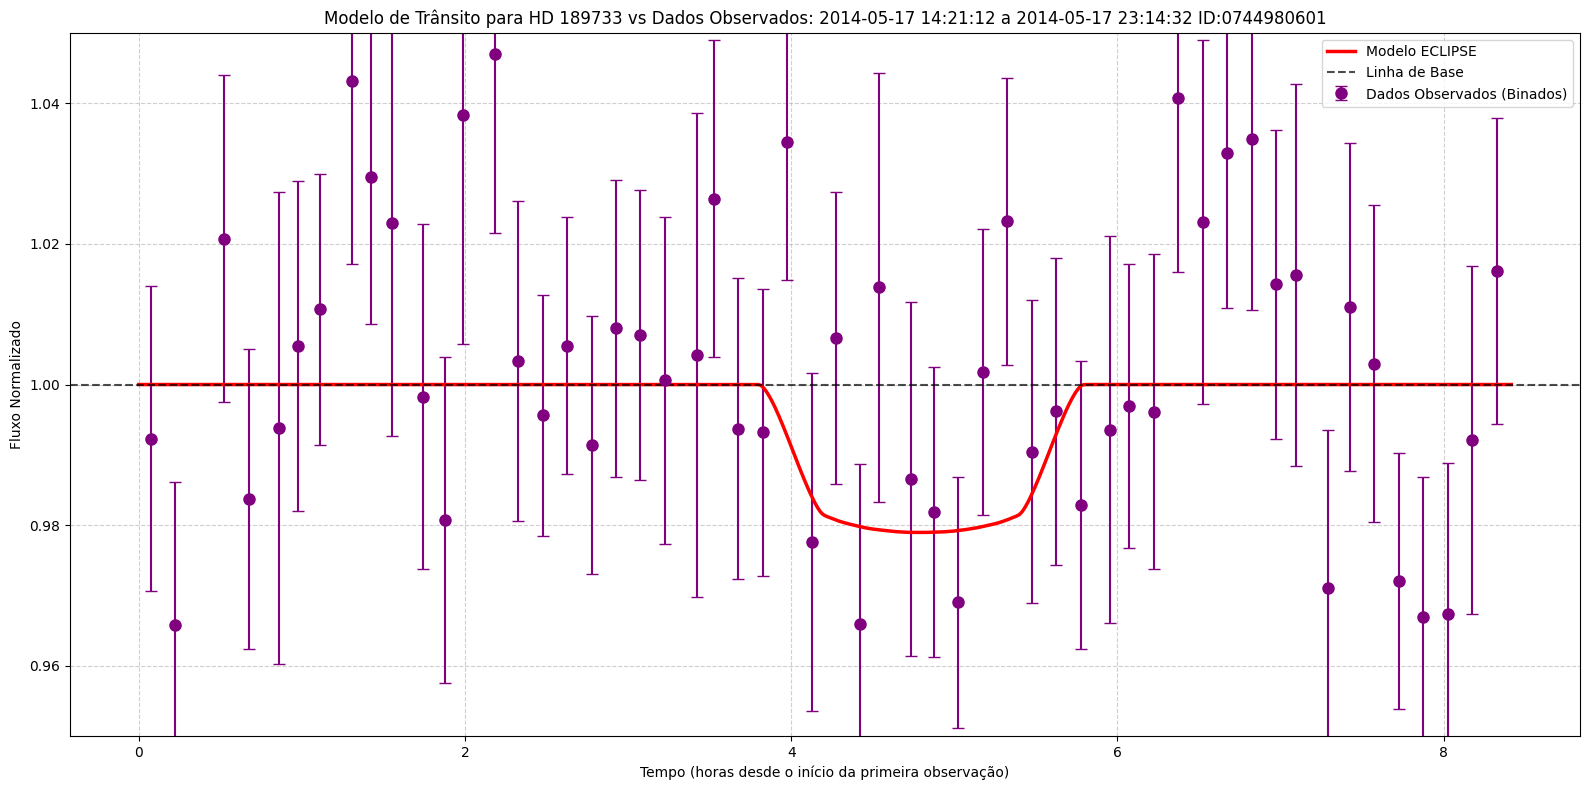

In [264]:
date_obs = "2014-05-17 14:21:12 a 2014-05-17 23:14:32"
id_obs = "0744980601"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980601/pps/'
parametros_modelo['t0']= 4.8147 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 9) 2014-11-11 00:37:26 a 2014-11-11 12:50:46
0744981201

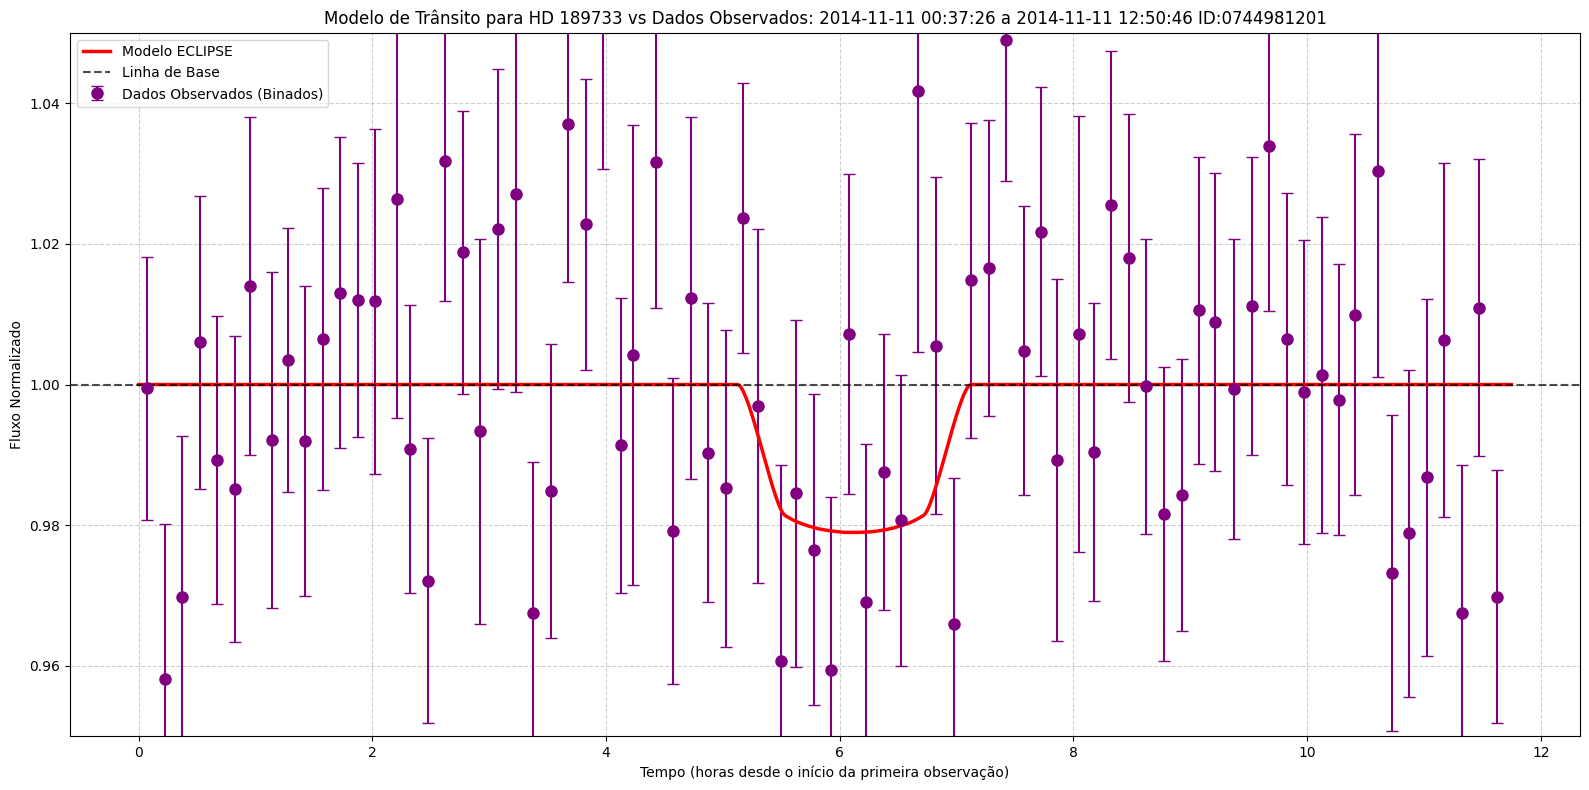

In [263]:
date_obs = "2014-11-11 00:37:26 a 2014-11-11 12:50:46"
id_obs = "0744981201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981201/pps/'
parametros_modelo['t0']= 6.1414 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 10) 2014-11-15 09:48:00 a 2014-11-15 20:38:00
0744980701

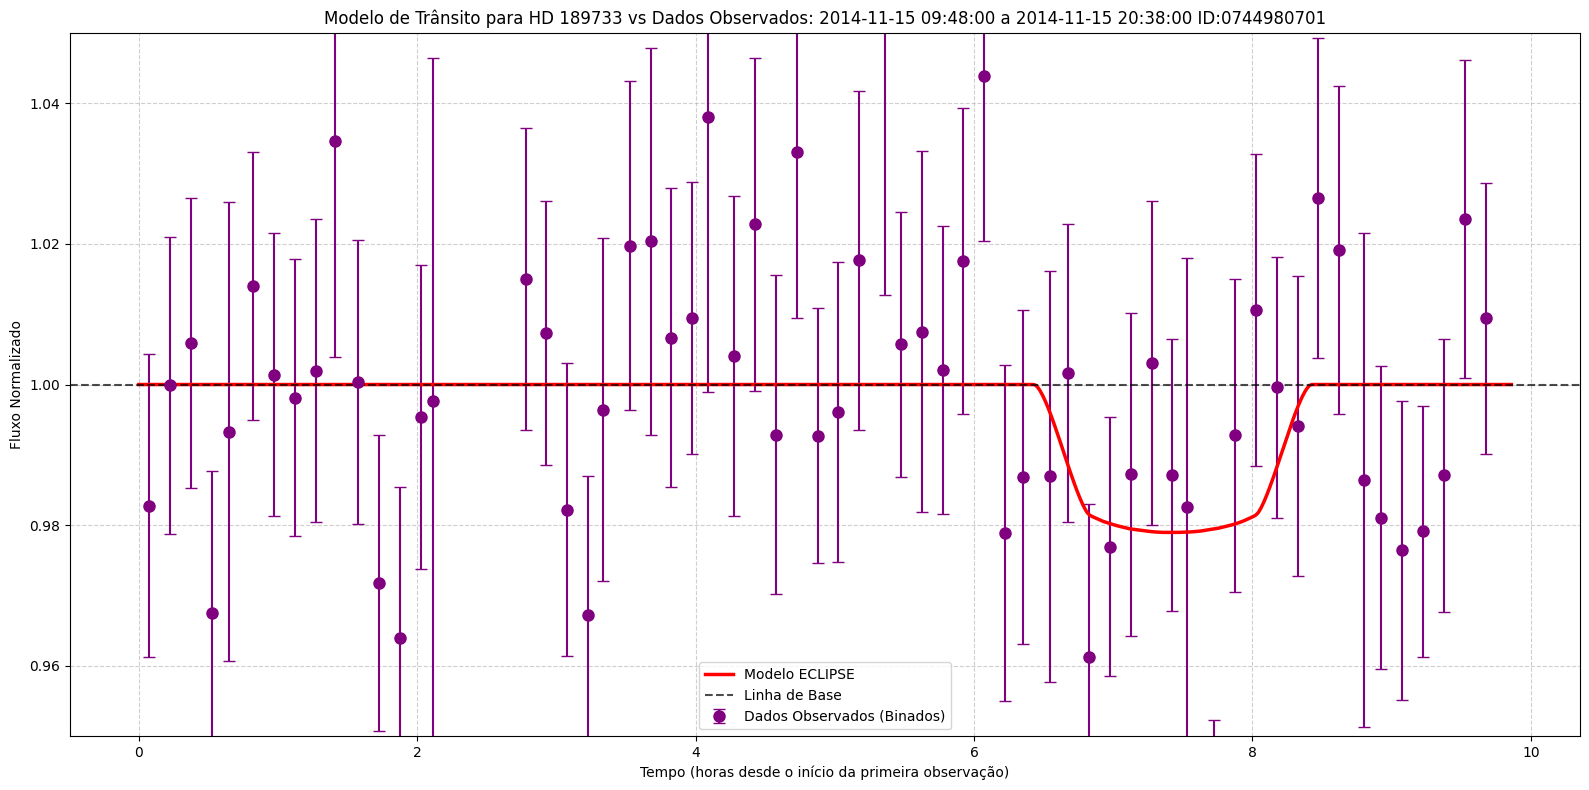

In [265]:
date_obs = "2014-11-15 09:48:00 a 2014-11-15 20:38:00"
id_obs = "0744980701"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980701/pps/'
parametros_modelo['t0']= 7.4447 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# Média das curvas

In [6]:
def processar_curva_de_luz_para_empilhar(pasta_dados, t0_centro_transito, periodo_dias):
    """
    Função para carregar e processar uma curva de luz.
    Retorna os dados NÃO-BINADOS, mas já em fase orbital.
    """
    padrao_arquivo = '*OM*TIMESR*.FTZ'
    caminho_busca = os.path.join(pasta_dados, padrao_arquivo)
    lista_arquivos = glob.glob(caminho_busca)
    
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    erros_ordenados = todos_erros[indices_ordenados]
    
    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    
    mask_fora_transito = np.abs(tempos_em_horas - t0_centro_transito) > 1.5
    fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
    fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
    erros_normalizados = erros_ordenados / fluxo_fora_transito
    
    periodo_em_horas = periodo_dias * 24.0
    fase_observada = (tempos_em_horas - t0_centro_transito) / periodo_em_horas
            
    return fase_observada, fluxos_normalizados, erros_normalizados

 -> Processando 2007-04-17...
 -> Processando 2012-06-07...
 -> Processando 2011-05-01...
 -> Processando 2014-11-13...
 -> Processando 2015-04-17...
 -> Processando 2015-04-19...
 -> Processando 2014-10-1...
 -> Processando 2014-11-11...
 -> Processando 2014-05-17...
 -> Processando 2014-11-15...
Processamento concluído!


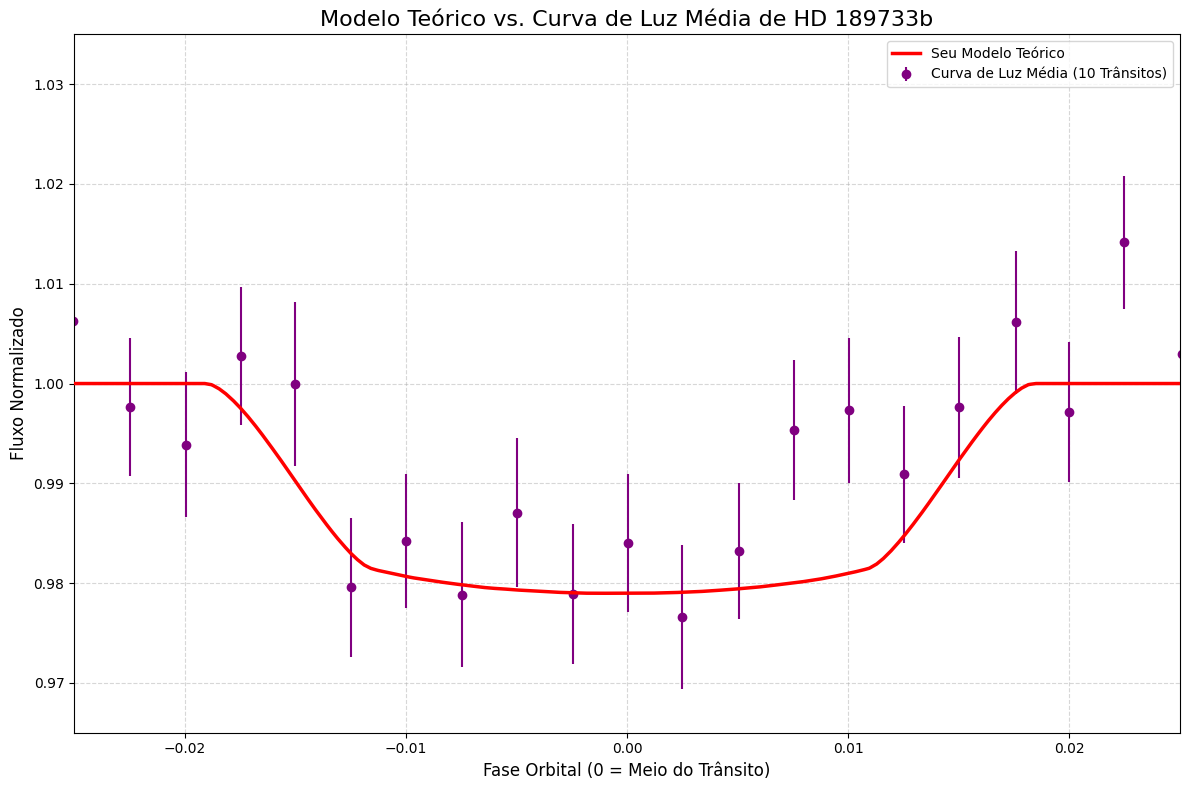

In [7]:
# --- 1. CONFIGURAÇÃO ---
observacoes = [
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/', 
        't0': 9.5161,
        'label': '2007-04-17'
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/',
        't0': 7.4245,
        'label': '2012-06-07'
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/', 
        't0': 7.8336,
        'label': '2011-05-01' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/', 
        't0': 5.2427,
        'label': '2014-11-13' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981601/pps/', 
        't0': 6.8033,
        'label': '2015-04-17' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981701/pps/', 
        't0': 4.5239,
        'label': '2015-04-19' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980801/pps/', 
        't0': 4.695,
        'label': '2014-10-1' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981201/pps/', 
        't0': 6.1414,
        'label': '2014-11-11' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980601/pps/', 
        't0': 4.8147,
        'label': '2014-05-17' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980701/pps/', 
        't0': 7.4447,
        'label': '2014-11-15' 
    },
]
periodo_geral_dias = 2.21857520

# --- 2. PROCESSAR E COMBINAR (Como antes) ---
todas_as_fases, todos_os_fluxos = [], []
for obs in observacoes:
    print(f" -> Processando {obs['label']}...")
    fase, fluxo, _ = processar_curva_de_luz_para_empilhar(obs['pasta'], obs['t0'], periodo_geral_dias)

    todas_as_fases.append(fase)
    todos_os_fluxos.append(fluxo)

print("Processamento concluído!")
fases_combinadas = np.concatenate(todas_as_fases)
fluxos_combinados = np.concatenate(todos_os_fluxos)

# --- 3. BINAR O CONJUNTO COMBINADO (Como antes) ---
bin_size_fase = 0.0025
bins = np.arange(fases_combinadas.min(), fases_combinadas.max(), bin_size_fase)
binned_fase, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (fases_combinadas >= bins[i]) & (fases_combinadas < bins[i+1])
    if np.sum(mask) > 1:
        binned_fase.append(np.mean(fases_combinadas[mask]))
        binned_flux.append(np.mean(fluxos_combinados[mask]))
        n_points = len(fluxos_combinados[mask])
        binned_error.append(np.std(fluxos_combinados[mask]) / np.sqrt(n_points))

# --- NOVO! 4. GERAR O MODELO TEÓRICO ---
parametros_modelo = {
    'rsun': 0.805, 
    'u1': 0.377, 
    'u2': 0.024, 
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031, 
    'angulo_inclinacao': 85.51, 
    'periodo': periodo_geral_dias,
    't0': 0.0 # O centro do nosso modelo é em t=0 horas, pois vamos plotar em fase
}
# Criar um eixo de fase suave para a linha do modelo
fase_modelo_plot = np.linspace(-0.025, 0.025, 1000)
# Converter o eixo de fase para um eixo de tempo em horas, centrado em zero
periodo_em_horas = periodo_geral_dias * 24.0
tempo_modelo_horas = fase_modelo_plot * periodo_em_horas
# Chamar sua função de modelo para gerar o fluxo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_horas, parametros_modelo)


# --- 5. PLOTAGEM FINAL ---
plt.figure(figsize=(12, 8))

# Plota a curva de luz média binada
plt.errorbar(binned_fase, binned_flux, yerr=binned_error, fmt='o', color='purple', markersize=6, ecolor='purple', capsize=0, label=f'Curva de Luz Média ({len(observacoes)} Trânsitos)')

# Plota o seu modelo teórico por cima
plt.plot(fase_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, zorder=10, label='Seu Modelo Teórico')

plt.title(f'Modelo Teórico vs. Curva de Luz Média de HD 189733b', fontsize=16)
plt.xlabel('Fase Orbital (0 = Meio do Trânsito)', fontsize=12)
plt.ylabel('Fluxo Normalizado', fontsize=12)
plt.xlim(-0.025, 0.025)
plt.ylim(0.965, 1.035)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Comparações com o modelo da média

--------------------------------------------------
ANÁLISE ESTATÍSTICA DOS RESÍDUOS
(Comparando a observação de 2011-05-01 com a média)
--------------------------------------------------
Valor do Qui-quadrado Reduzido (χ²ν): 1.8721
Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere
que a diferença entre esta observação e a média é maior que o ruído esperado.
==> Conclusão Numérica: Esta observação pode conter um evento anômalo.
--------------------------------------------------


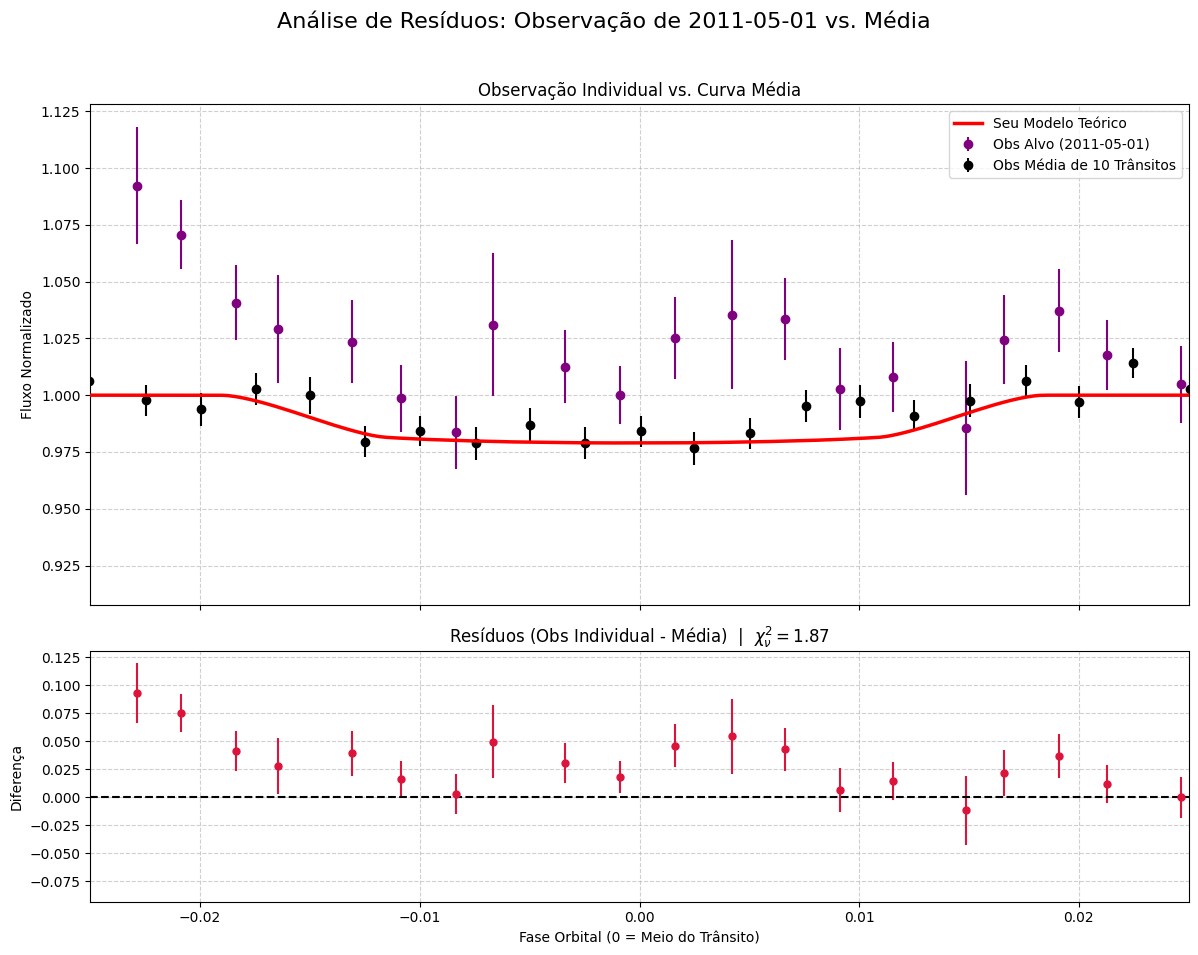

In [8]:
periodo_geral_dias = 2.21857520

indice_da_obs_alvo = 2 # interessante 2 

fase_media, fluxo_medio, erro_medio = binned_fase, binned_flux, binned_error

# --- 3. PROCESSAR A OBSERVAÇÃO ALVO INDIVIDUALMENTE ---
obs_alvo = observacoes[indice_da_obs_alvo]
fase_alvo, fluxo_alvo, erro_alvo = processar_curva_de_luz_para_empilhar(obs_alvo['pasta'], obs_alvo['t0'], periodo_geral_dias)

# Binning da observação alvo para ter menos pontos
binned_fase_alvo, binned_fluxo_alvo, binned_erro_alvo = [], [], []
bins_alvo = np.arange(fase_alvo.min(), fase_alvo.max(), bin_size_fase)
for i in range(len(bins_alvo) - 1):
    mask = (fase_alvo >= bins_alvo[i]) & (fase_alvo < bins_alvo[i+1])
    if np.sum(mask) > 0: # > 0 para não perder bins com poucos pontos
        binned_fase_alvo.append(np.mean(fase_alvo[mask]))
        binned_fluxo_alvo.append(np.mean(fluxo_alvo[mask]))
        n_points = len(fluxo_alvo[mask])
        binned_erro_alvo.append(np.std(fluxo_alvo[mask]) / np.sqrt(n_points))
binned_fase_alvo, binned_fluxo_alvo, binned_erro_alvo = np.array(binned_fase_alvo), np.array(binned_fluxo_alvo), np.array(binned_erro_alvo)


# --- 4. SUBTRAIR A MÉDIA DA OBSERVAÇÃO ALVO ---
# Interpolar a curva média para os pontos de fase da observação alvo
fluxo_medio_interp = np.interp(binned_fase_alvo, fase_media, fluxo_medio)
erro_medio_interp = np.interp(binned_fase_alvo, fase_media, erro_medio)

# Calcular os resíduos
residuos = binned_fluxo_alvo - fluxo_medio_interp
erro_residuos = np.sqrt(binned_erro_alvo**2 + erro_medio_interp**2)

# --- 5. ANÁLISE ESTATÍSTICA DOS RESÍDUOS ---
modelo = np.zeros_like(residuos)
dados_observados = residuos
incerteza = erro_residuos
qui_quadrado = np.sum(((dados_observados - modelo) / incerteza)**2)
graus_de_liberdade = len(dados_observados) - 1
qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade

print("-" * 50)
print("ANÁLISE ESTATÍSTICA DOS RESÍDUOS")
print(f"(Comparando a observação de {obs_alvo['label']} com a média)")
print("-" * 50)
print(f"Valor do Qui-quadrado Reduzido (χ²ν): {qui_quadrado_reduzido:.4f}")

if 0.7 <= qui_quadrado_reduzido <= 1.5:
    print("Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença")
    print("entre esta observação e a média é consistente com o ruído esperado.")
    print("==> Conclusão Numérica: A observação alvo é estatisticamente 'normal'.")
elif qui_quadrado_reduzido > 1.5:
    print("Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere")
    print("que a diferença entre esta observação e a média é maior que o ruído esperado.")
    print("==> Conclusão Numérica: Esta observação pode conter um evento anômalo.")
else: 
    print("Interpretação: Interessante. Um valor muito menor que 1.0 pode indicar")
    print("que as barras de erro dos dados foram superestimadas.")
print("-" * 50)

# --- 6. PLOTAGEM FINAL ---
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'Análise de Resíduos: Observação de {obs_alvo["label"]} vs. Média', fontsize=16)

# Painel Superior: Comparação
axs[0].errorbar(binned_fase_alvo, binned_fluxo_alvo, yerr=binned_erro_alvo, fmt='o', color='purple', label=f"Obs Alvo ({obs_alvo['label']})")
axs[0].errorbar(fase_media, fluxo_medio, yerr=erro_medio, fmt='o', color='black', label=f"Obs Média de {len(observacoes)} Trânsitos")
axs[0].plot(fase_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, zorder=10, label='Seu Modelo Teórico')
#axs[0].plot(fase_media, fluxo_medio, color='black', linewidth=2, label=f"Média de {len(observacoes)} Trânsitos")
axs[0].set_title('Observação Individual vs. Curva Média')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Painel Inferior: Resíduos
axs[1].errorbar(binned_fase_alvo, residuos, yerr=erro_residuos, fmt='o', color='crimson', markersize=5)
axs[1].axhline(0, color='black', linestyle='--')
# --- MUDANÇA: Adiciona o valor de chi2 ao título do gráfico de resíduos ---
axs[1].set_title(f'Resíduos (Obs Individual - Média)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[1].set_ylabel('Diferença')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.xlim(-0.025, 0.025)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Aplicação de filtro

In [9]:
from scipy.signal import savgol_filter

In [10]:
binned_fluxo_medio_smooth = savgol_filter(fluxo_medio, window_length=11, polyorder=3)
binned_fluxo_alvo_smooth = savgol_filter(binned_fluxo_alvo, window_length=11, polyorder=3)

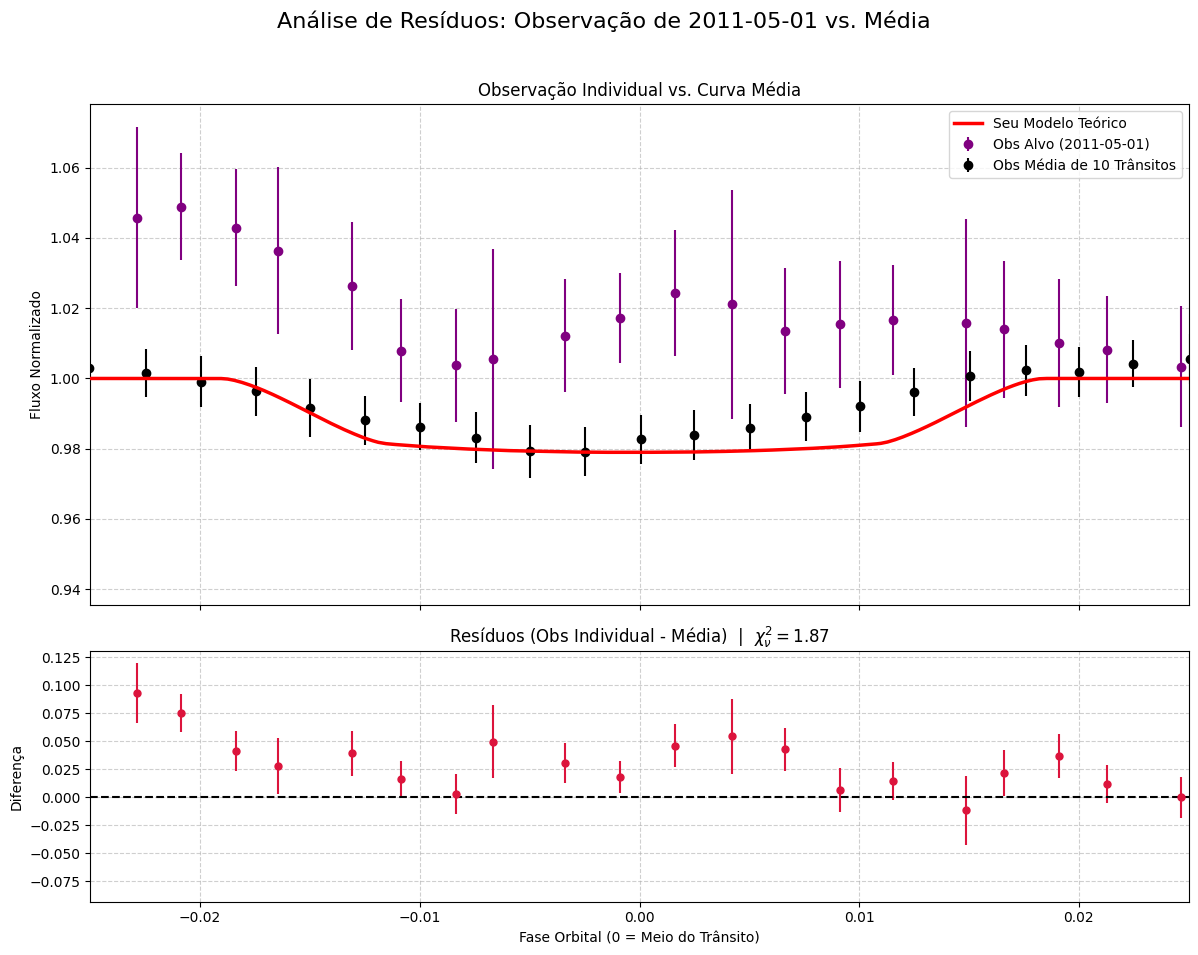

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'Análise de Resíduos: Observação de {obs_alvo["label"]} vs. Média', fontsize=16)

axs[0].errorbar(binned_fase_alvo, binned_fluxo_alvo_smooth, yerr=binned_erro_alvo, fmt='o', color='purple', label=f"Obs Alvo ({obs_alvo['label']})")
axs[0].errorbar(fase_media, binned_fluxo_medio_smooth, yerr=erro_medio, fmt='o', color='black', label=f"Obs Média de {len(observacoes)} Trânsitos")
axs[0].plot(fase_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, zorder=10, label='Seu Modelo Teórico')

axs[0].set_title('Observação Individual vs. Curva Média')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

axs[1].errorbar(binned_fase_alvo, residuos, yerr=erro_residuos, fmt='o', color='crimson', markersize=5)
axs[1].axhline(0, color='black', linestyle='--')

axs[1].set_title(f'Resíduos (Obs Individual - Média)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[1].set_ylabel('Diferença')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.xlim(-0.025, 0.025)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# MCMC

In [12]:
parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.0618,
    'u2': 0.0204,
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031,
    'angulo_inclinacao': 85.710,
    'periodo': 2.21857520,
    'mass_planeta': 1.138,
    # Parâmetro medido dos dados para alinhamento
    't0': 1 # Centro do trânsito default
}

In [13]:
# Parâmetros resultados no primeiro mcmc 
u1 = parametros_modelo['u1']
u2 = parametros_modelo['u2']
semi_eixo_UA = parametros_modelo['semi_eixo_UA']
angulo_inclinacao = parametros_modelo['angulo_inclinacao']
raio_plan_Jup = parametros_modelo['raio_plan_Jup']

estrela_ = Estrela(373, parametros_modelo['rsun'], 240., u1, u2, 856)
estrela_.setStarName("HD189733 A")
estrela_.setCadence("fast")

Nx = estrela_.getNx()
Ny = estrela_.getNy()
raioEstrelaPixel = estrela_.getRaioStar()

planeta_= Planeta(semi_eixo_UA, raio_plan_Jup, parametros_modelo['periodo'], angulo_inclinacao, 0, 0, estrela_.getRaioSun(), parametros_modelo['mass_planeta'])

eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_)
eclipse.setTempoHoras(5) 


In [14]:
# add flare
raio_flare = 0.15
intensidade_flare = 1.6
latitude_flare = -39
longitude_flare = -28

flare = Estrela.Facula(intensidade_flare, raio_flare, latitude_flare, longitude_flare)
#facula2 = Estrela.Facula(1.5, 0.08, latitude_facula, longitude_facula) #caso queira adicionar mais fáculas


estrela_.addFacula(flare)
#estrela_.addFacula(facula2)

estrela_.criaEstrelaComFaculas()
estrela_matriz = estrela_.getMatrizEstrela()

In [15]:
estrela_matriz = estrela_.getMatrizEstrela()

temperatura_cme = estrela_.temperaturaEfetiva # temperatura da CME (em K) 4875.0
raio_cme = 60 # em ??
distancia_planeta = 0 #em km d = semi-eixoau*1.5e8
velocidade_cme = 0.7 #tempo = d / v_CME
opacidade = 0.8
p0x = 340
p0y = 230
p1x = 430
p1y = 200
taxa_esfriamento = 35
cme = Estrela.EjecaoMassa(raio_cme, p0x, p0y, p1x, p1y, opacidade, temperatura_cme, velocidade_cme, taxa_esfriamento)

estrela_.addCme(cme)
#estrela_.ejecaoDeMassa(temperatura_cme, raio_cme)

1.0677399635314941


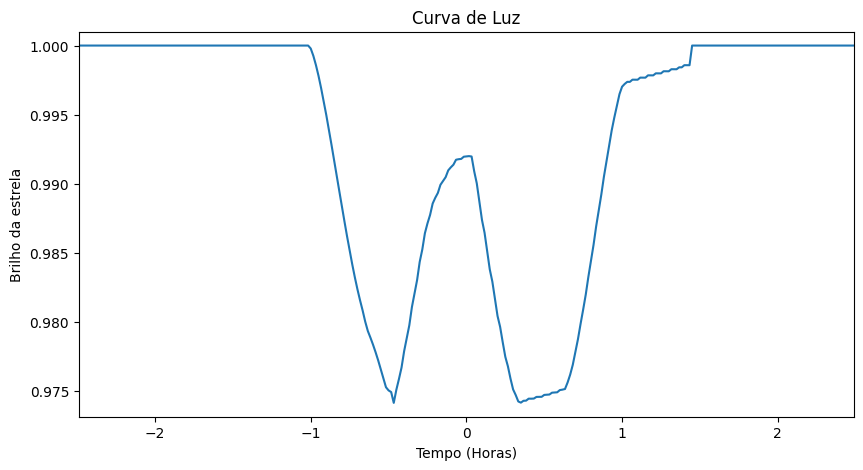

Tempo Total (Trânsito): 4.978435644173519


In [16]:
#eclipse
estrela_matriz = estrela_.getMatrizEstrela()
eclipse.setEstrela(estrela_matriz)
eclipse.criarEclipse(anim=False)

print ("Tempo Total (Trânsito):", eclipse.getTempoTransito()) 
tempoTransito = eclipse.getTempoTransito()
curvaLuz = eclipse.getCurvaLuz()
tempoHoras = eclipse.getTempoHoras()

In [17]:
def plotLegendModel(ax, mission): 
 # Adicionando título e legendas dos eixos
    ax.set_title(f'Curva de luz extraída do Telescópio {mission} x Curva de luz modelo')
    ax.set_xlabel('Eixo X (Tempo)')
    ax.set_ylabel('Eixo Y (Brilho da estrela)')

    # Exibindo a legenda
    ax.legend()
    plt.show()

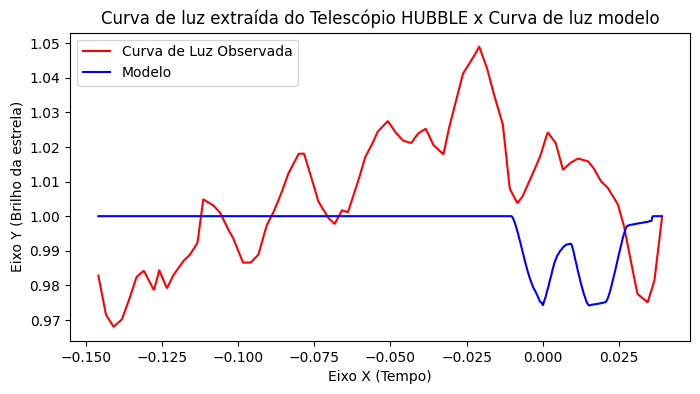

In [18]:
lc_modelo_raw = np.array(eclipse.getCurvaLuz()) 
tempo_modelo_raw_horas = np.array(eclipse.getTempoHoras())

# --- 2. ALINHAR O MODELO EM FASE ORBITAL ---
lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
meio_transito_no_modelo_horas = tempo_modelo_raw_horas[np.argmin(lc_modelo_normalizado)]
tempo_modelo_centralizado = tempo_modelo_raw_horas - meio_transito_no_modelo_horas
periodo_em_horas = periodo_geral_dias * 24.0
fase_do_modelo = (tempo_modelo_centralizado) / periodo_em_horas

# --- 3. INTERPOLAR AMBAS AS CURVAS PARA UM EIXO COMUM ---
# Primeiro, garantimos que as listas dos dados observados sejam arrays NumPy
#binned_fase_alvo, binned_fluxo_alvo_smooth
binned_fase_alvo = np.array(binned_fase_alvo)
binned_fluxo_alvo_smooth = np.array(binned_fluxo_alvo_smooth)
# -----------------------------

fase_plot_final = np.linspace(binned_fase_alvo.min(), binned_fase_alvo.max(), 1000)

# Mapeamos (interpolamos) a curva de luz observada para o novo eixo
fluxo_observado_interp = np.interp(fase_plot_final, binned_fase_alvo, binned_fluxo_alvo_smooth)

# Mapeamos (interpolamos) a curva de luz do seu modelo para o novo eixo
fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)

# --- 4. PLOTAGEM FINAL CORRIGIDA ---
plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

mission = "HUBBLE"

ax.plot(fase_plot_final, fluxo_observado_interp, "r-", label='Curva de Luz Observada')
ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Modelo')
plotLegendModel(ax, mission) 

# ax.set_xlabel("Fase Orbital (0 = Meio do Trânsito)")
# ax.set_ylabel("Fluxo Normalizado")
# ax.grid(True, linestyle='--')
# ax.legend()
# plt.show()

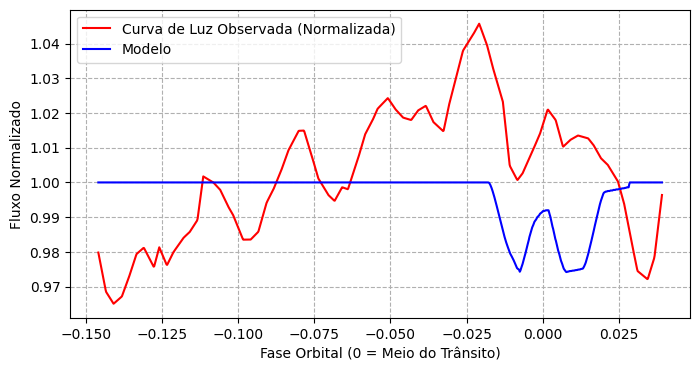

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Supondo que o seu código anterior já foi executado e você tem as variáveis:
# lc_modelo_raw, tempo_modelo_raw_horas, binned_fase_alvo, binned_fluxo_alvo_smooth
# periodo_geral_dias = 2.21857520 (Exemplo)

# --- 2. ALINHAR O MODELO EM FASE ORBITAL ---
lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
meio_transito_no_modelo_horas = tempo_modelo_raw_horas[np.argmin(lc_modelo_normalizado)]
tempo_modelo_centralizado = tempo_modelo_raw_horas - meio_transito_no_modelo_horas
periodo_em_horas = (periodo_geral_dias) * 24.0
fase_do_modelo = (tempo_modelo_centralizado - 0.4) / periodo_em_horas #ajustar centralizacao aqui

# --- 3. NORMALIZAÇÃO E INTERPOLAÇÃO ---
binned_fase_alvo = np.array(binned_fase_alvo)
binned_fluxo_alvo_smooth = np.array(binned_fluxo_alvo_smooth)

# --- NOVO BLOCO DE CÓDIGO PARA NORMALIZAÇÃO PRECISA ---

# 1. Definir a janela do trânsito em unidades de fase
duracao_total_horas = 1.8
meia_duracao_em_fase = (duracao_total_horas / 2.0) / periodo_em_horas

# 2. Identificar os pontos que estão FORA do trânsito
# Usamos o valor absoluto da fase para pegar os dois lados da curva (antes e depois)
mask_fora_transito = np.abs(binned_fase_alvo) > meia_duracao_em_fase

# 3. Calcular o fluxo médio apenas desses pontos fora do trânsito
fluxo_de_referencia = np.mean(binned_fluxo_alvo_smooth[mask_fora_transito])

# 4. Normalizar a curva de luz inteira por este fator
# Esta nova variável contém a curva de luz perfeitamente normalizada
# fluxo_observado_normalizado = binned_fluxo_alvo_smooth-0.03 / fluxo_de_referencia
fluxo_observado_normalizado = binned_fluxo_alvo_smooth / fluxo_de_referencia

# --- FIM DO NOVO BLOCO ---

# Criar um eixo de fase comum
fase_plot_final = np.linspace(binned_fase_alvo.min(), binned_fase_alvo.max(), 1000)

# Mapear (interpolar) a curva de luz OBSERVADA e NORMALIZADA para o novo eixo
fluxo_observado_interp = np.interp(fase_plot_final, binned_fase_alvo, fluxo_observado_normalizado) 

# Mapear (interpolar) a curva de luz do seu modelo para o novo eixo
fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)


# --- 4. PLOTAGEM FINAL CORRIGIDA ---
plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

mission = "HUBBLE"

# --- MUDANÇA AQUI: plotar a curva normalizada ---
ax.plot(fase_plot_final, fluxo_observado_interp, "r-", label='Curva de Luz Observada (Normalizada)')
ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Modelo')
# plotLegendModel(ax, mission) # Sua função de legenda

ax.set_xlabel("Fase Orbital (0 = Meio do Trânsito)")
ax.set_ylabel("Fluxo Normalizado")
ax.grid(True, linestyle='--')
ax.legend()
plt.show()

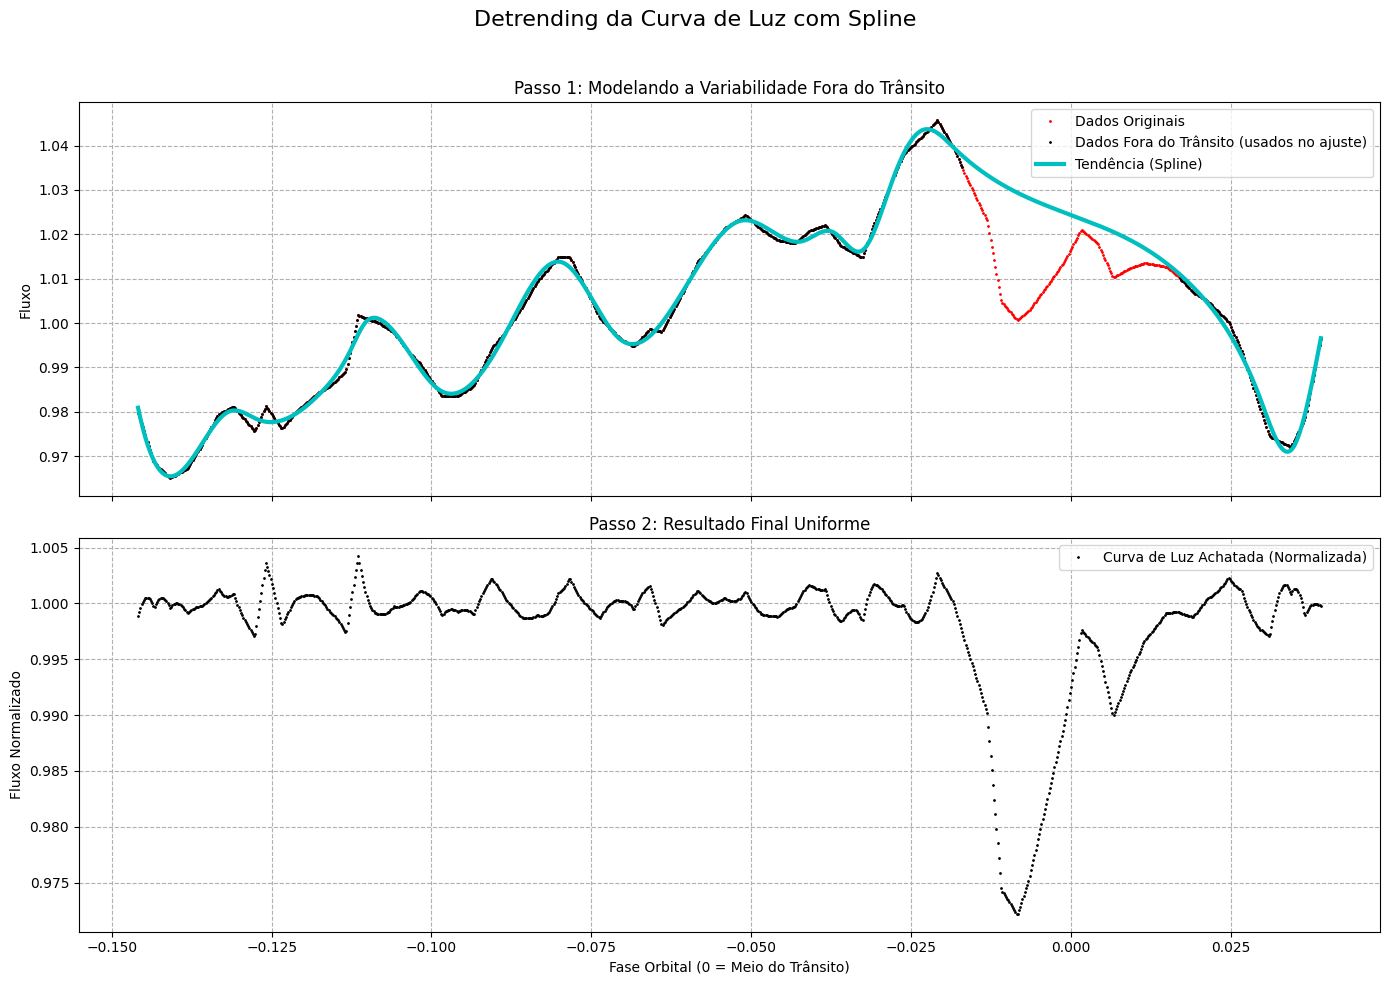

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# --- 2. LÓGICA DE DETRENDING COM SPLINE ---

# 1. Definir a janela do trânsito para poder ignorá-la
duracao_total_horas = 1.8
periodo_em_horas = 2.21857520 * 24.0
meia_duracao_em_fase = (duracao_total_horas / 2.0) / periodo_em_horas

# 2. Criar uma máscara para selecionar apenas os pontos FORA do trânsito
mask_fora_transito = np.abs(fase_plot_final) > meia_duracao_em_fase

# 3. Ajustar a Spline USANDO APENAS os dados de fora do trânsito
#    Isso ensina à Spline qual é a tendência de "eventos" da estrela
spl = UnivariateSpline(fase_plot_final[mask_fora_transito], fluxo_observado_interp[mask_fora_transito], s=0.001)

# 4. Gerar a curva de tendência para TODOS os pontos de tempo
tendencia_spline = spl(fase_plot_final)

# 5. Normalizar: Dividir a curva de luz original pela tendência encontrada
fluxo_final_achatado = fluxo_observado_interp / tendencia_spline


# --- 3. PLOTAGEM DOS RESULTADOS ---
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Detrending da Curva de Luz com Spline', fontsize=16)

# Painel Superior: O Ajuste da Tendência
axs[0].plot(fase_plot_final, fluxo_observado_interp, 'r.', markersize=2, label='Dados Originais')
axs[0].plot(fase_plot_final[mask_fora_transito], fluxo_observado_interp[mask_fora_transito], 'k.', markersize=2, label='Dados Fora do Trânsito (usados no ajuste)')
axs[0].plot(fase_plot_final, tendencia_spline, 'c-', linewidth=3, label='Tendência (Spline)')
axs[0].set_title('Passo 1: Modelando a Variabilidade Fora do Trânsito')
axs[0].set_ylabel('Fluxo')
axs[0].legend()
axs[0].grid(True, linestyle='--')

# Painel Inferior: O Resultado Final
axs[1].plot(fase_plot_final, fluxo_final_achatado, 'k.', markersize=2, label='Curva de Luz Achatada (Normalizada)')
axs[1].set_title('Passo 2: Resultado Final Uniforme')
axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[1].set_ylabel('Fluxo Normalizado')
axs[1].legend()
axs[1].grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

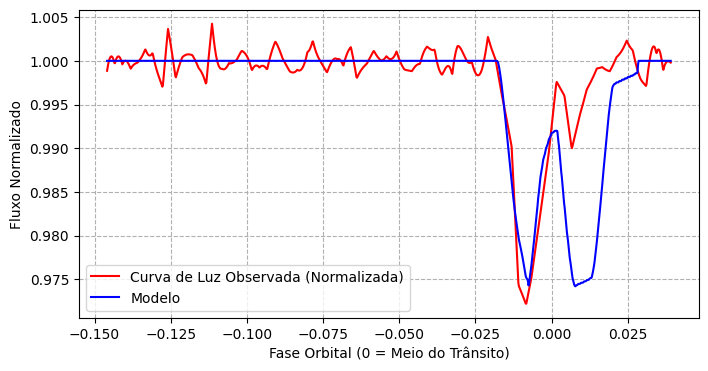

In [21]:
# --- 4. PLOTAGEM FINAL CORRIGIDA ---
plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

mission = "HUBBLE"

# --- MUDANÇA AQUI: plotar a curva normalizada ---
ax.plot(fase_plot_final, fluxo_final_achatado, "r-", label='Curva de Luz Observada (Normalizada)')
ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Modelo')
# plotLegendModel(ax, mission) # Sua função de legenda

ax.set_xlabel("Fase Orbital (0 = Meio do Trânsito)")
ax.set_ylabel("Fluxo Normalizado")
ax.grid(True, linestyle='--')
ax.legend()
plt.show()

In [22]:
from Adjust.Adjust import AjusteCME
from Adjust.Model import Modelo

In [24]:
nwalkers = 20
niter = 20
burnin = 10
ndim = 1

modelo = Modelo(estrela_, eclipse, "HUBBLE")
# fluxo_modelo_interp 
ajusteCME = AjusteCME(modelo, fase_plot_final, fluxo_final_achatado, nwalkers, niter, burnin, ndim, eclipse, cme, parametros_modelo['rsun'], parametros_modelo['periodo'])

time = fase_plot_final
flux = fluxo_final_achatado

In [25]:
sampler, pos, prob, state = ajusteCME.main()

Running burn-in...


100%|██████████| 10/10 [03:44<00:00, 22.43s/it]


Running production...


100%|██████████| 20/20 [07:54<00:00, 23.71s/it]


In [26]:
samples = sampler.flatchain
samples[np.argmax(sampler.flatlnprobability)]

array([ 52.33933428, 335.96479156, 240.0364612 , 421.08296391,
       180.57771993,   0.92024992,   0.70905352,  33.7535002 ])

In [27]:
theta_max  = samples[np.argmax(sampler.flatlnprobability)]
print(theta_max)
best_fit_model = ajusteCME.eclipse_mcmc(time, theta_max)

[ 52.33933428 335.96479156 240.0364612  421.08296391 180.57771993
   0.92024992   0.70905352  33.7535002 ]


In [28]:
def plotLegendAdjust(plot, mission): 
    # Adicionando título e legendas dos eixos
    plot.title(f'Curva de luz extraída do Telescópio {mission} x Curva de luz ajustada')
    plot.xlabel('Eixo X (Tempo)')
    plot.ylabel('Eixo Y (Brilho da estrela)')

    # Exibindo a legenda
    plot.legend()
    plot.show()

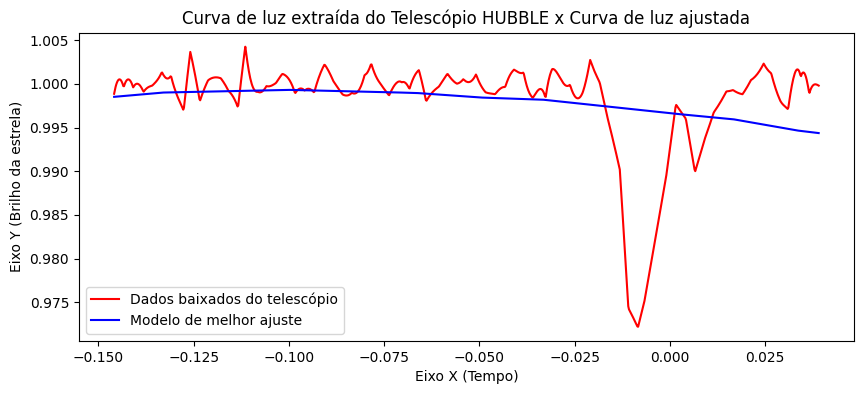

Theta max:  [ 52.33933428 335.96479156 240.0364612  421.08296391 180.57771993
   0.92024992   0.70905352  33.7535002 ]


In [29]:
### Plotagem de resultados #### 
plt.rcParams['figure.figsize']= 10, 4
graf1,ax = plt.subplots()
plt.plot(time, flux, label = 'Dados baixados do telescópio',color="red")
plt.plot(time, best_fit_model, label='Modelo de melhor ajuste',color="blue")
plotLegendAdjust(plt, "HUBBLE")

print('Theta max: ',theta_max)

# Comparações

In [197]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [198]:
def processar_curva_de_luz(pasta_dados, t0_centro_transito, periodo_dias):
    padrao_arquivo = '*OM*TIMESR*.FTZ'
    caminho_busca = os.path.join(pasta_dados, padrao_arquivo)
    lista_arquivos = glob.glob(caminho_busca)
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    erros_ordenados = todos_erros[indices_ordenados]
    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    mask_fora_transito = np.abs(tempos_em_horas - t0_centro_transito) > 1.5
    fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
    fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
    erros_normalizados = erros_ordenados / fluxo_fora_transito
    periodo_em_horas = periodo_dias * 24.0
    fase_observada = (tempos_em_horas - t0_centro_transito) / periodo_em_horas
    bin_size_fase = 0.005
    bins = np.arange(fase_observada.min(), fase_observada.max(), bin_size_fase)
    binned_fase, binned_flux, binned_error = [], [], []
    for i in range(len(bins) - 1):
        mask = (fase_observada >= bins[i]) & (fase_observada < bins[i+1])
        if np.sum(mask) > 0:
            binned_fase.append(np.mean(fase_observada[mask]))
            binned_flux.append(np.mean(fluxos_normalizados[mask]))
            n_points = len(fluxos_normalizados[mask])
            binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))
    return np.array(binned_fase), np.array(binned_flux), np.array(binned_error)

### Análise 1

--------------------------------------------------
ANÁLISE ESTATÍSTICA DOS RESÍDUOS
--------------------------------------------------
Valor do Qui-quadrado Reduzido (χ²ν): 1.6298
Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere
que a diferença entre as curvas é maior que o ruído esperado.
==> Conclusão Numérica: A variação entre os trânsitos pode ser real.
--------------------------------------------------


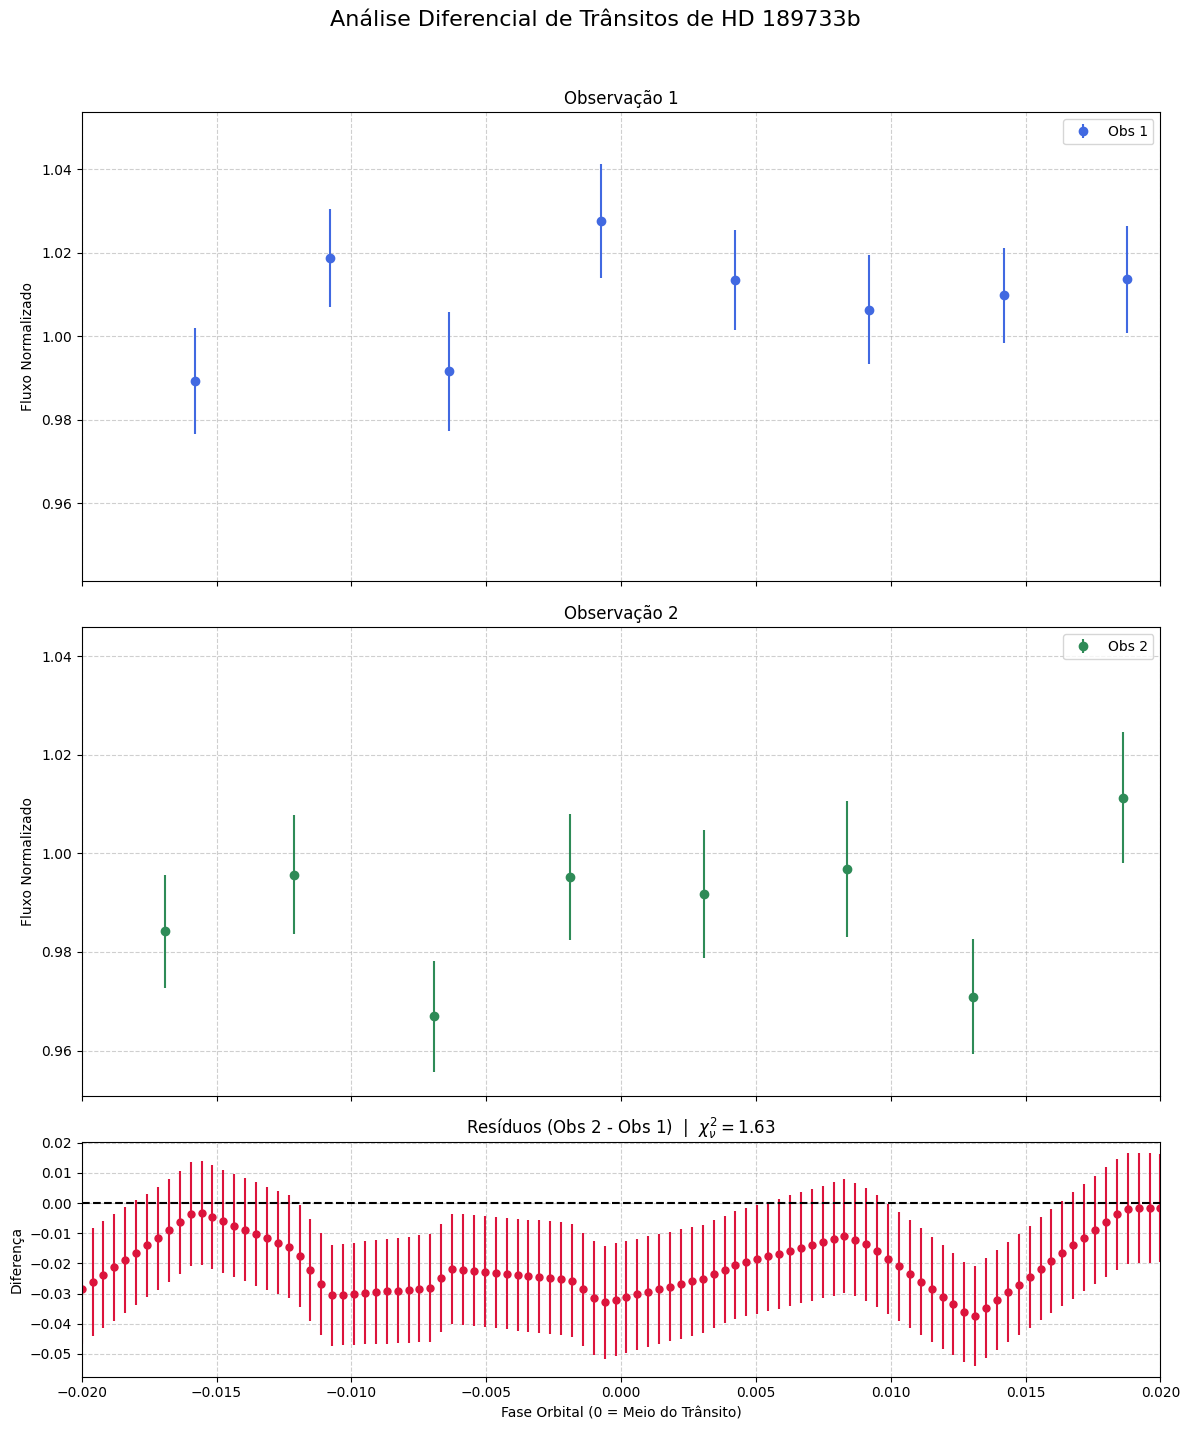

In [201]:
# --- 1. CONFIGURAÇÃO PRINCIPAL ---
pasta_obs_1 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
t0_obs_1 = 1.5058

pasta_obs_2 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/'
t0_obs_2 = 7.4245 

parametros_gerais = { 'periodo': 2.21857520 }

# --- 2. PROCESSAR E SUBTRAIR (Como antes) ---
fase1, fluxo1, erro1 = processar_curva_de_luz(pasta_obs_1, t0_obs_1, parametros_gerais['periodo'])
fase2, fluxo2, erro2 = processar_curva_de_luz(pasta_obs_2, t0_obs_2, parametros_gerais['periodo'])

fase_comum = np.linspace(-0.02, 0.02, num=100)
fluxo1_interp = np.interp(fase_comum, fase1, fluxo1)
erro1_interp = np.interp(fase_comum, fase1, erro1)
fluxo2_interp = np.interp(fase_comum, fase2, fluxo2)
erro2_interp = np.interp(fase_comum, fase2, erro2)

fluxo_residuo = fluxo2_interp - fluxo1_interp
erro_residuo = np.sqrt(erro1_interp**2 + erro2_interp**2)

# --- NOVO! 3. CÁLCULO DA MÉTRICA DE QUI-QUADRADO ---

# Nosso modelo (E) é a hipótese de "nenhuma diferença", ou seja, uma linha em y=0
modelo = np.zeros_like(fluxo_residuo)

# Nossos dados observados (O) são os resíduos
dados_observados = fluxo_residuo

# Nossa incerteza (sigma) é o erro dos resíduos
incerteza = erro_residuo

# Calcular o Qui-quadrado (Chi-squared)
qui_quadrado = np.sum(((dados_observados - modelo) / incerteza)**2)

# Calcular os graus de liberdade (número de pontos - número de parâmetros do modelo)
# Nosso modelo y=0 tem 1 parâmetro (a média, que é zero).
graus_de_liberdade = len(dados_observados) - 1

# Calcular o Qui-quadrado Reduzido
qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade

print("-" * 50)
print("ANÁLISE ESTATÍSTICA DOS RESÍDUOS")
print("-" * 50)
print(f"Valor do Qui-quadrado Reduzido (χ²ν): {qui_quadrado_reduzido:.4f}")

# Interpretação automática do resultado
if 0.7 <= qui_quadrado_reduzido <= 1.5:
    print("Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença")
    print("entre as curvas é consistente com o ruído esperado.")
    print("==> Conclusão Numérica: Os dois trânsitos são estatisticamente idênticos.")
elif qui_quadrado_reduzido > 1.5:
    print("Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere")
    print("que a diferença entre as curvas é maior que o ruído esperado.")
    print("==> Conclusão Numérica: A variação entre os trânsitos pode ser real.")
else: # qui_quadrado_reduzido < 0.7
    print("Interpretação: Interessante. Um valor muito menor que 1.0 pode indicar")
    print("que as barras de erro dos dados foram superestimadas.")
print("-" * 50)


# --- 4. PLOTAGEM FINAL (Como antes) ---
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
# ... (cole o código de plotagem da resposta anterior aqui)
fig.suptitle('Análise Diferencial de Trânsitos de HD 189733b', fontsize=16)
axs[0].errorbar(fase1, fluxo1, yerr=erro1, fmt='o', color='royalblue', label='Obs 1')
axs[0].set_title('Observação 1')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()
axs[1].errorbar(fase2, fluxo2, yerr=erro2, fmt='o', color='seagreen', label='Obs 2')
axs[1].set_title('Observação 2')
axs[1].set_ylabel('Fluxo Normalizado')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()
axs[2].errorbar(fase_comum, fluxo_residuo, yerr=erro_residuo, fmt='o', color='crimson', markersize=5)
axs[2].axhline(0, color='black', linestyle='--')
axs[2].set_title(f'Resíduos (Obs 2 - Obs 1)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[2].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[2].set_ylabel('Diferença')
axs[2].grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.02, 0.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Análise 2

--------------------------------------------------
ANÁLISE ESTATÍSTICA DOS RESÍDUOS
--------------------------------------------------
Valor do Qui-quadrado Reduzido (χ²ν): 1.2407
Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença
entre as curvas é consistente com o ruído esperado.
==> Conclusão Numérica: Os dois trânsitos são estatisticamente idênticos.
--------------------------------------------------


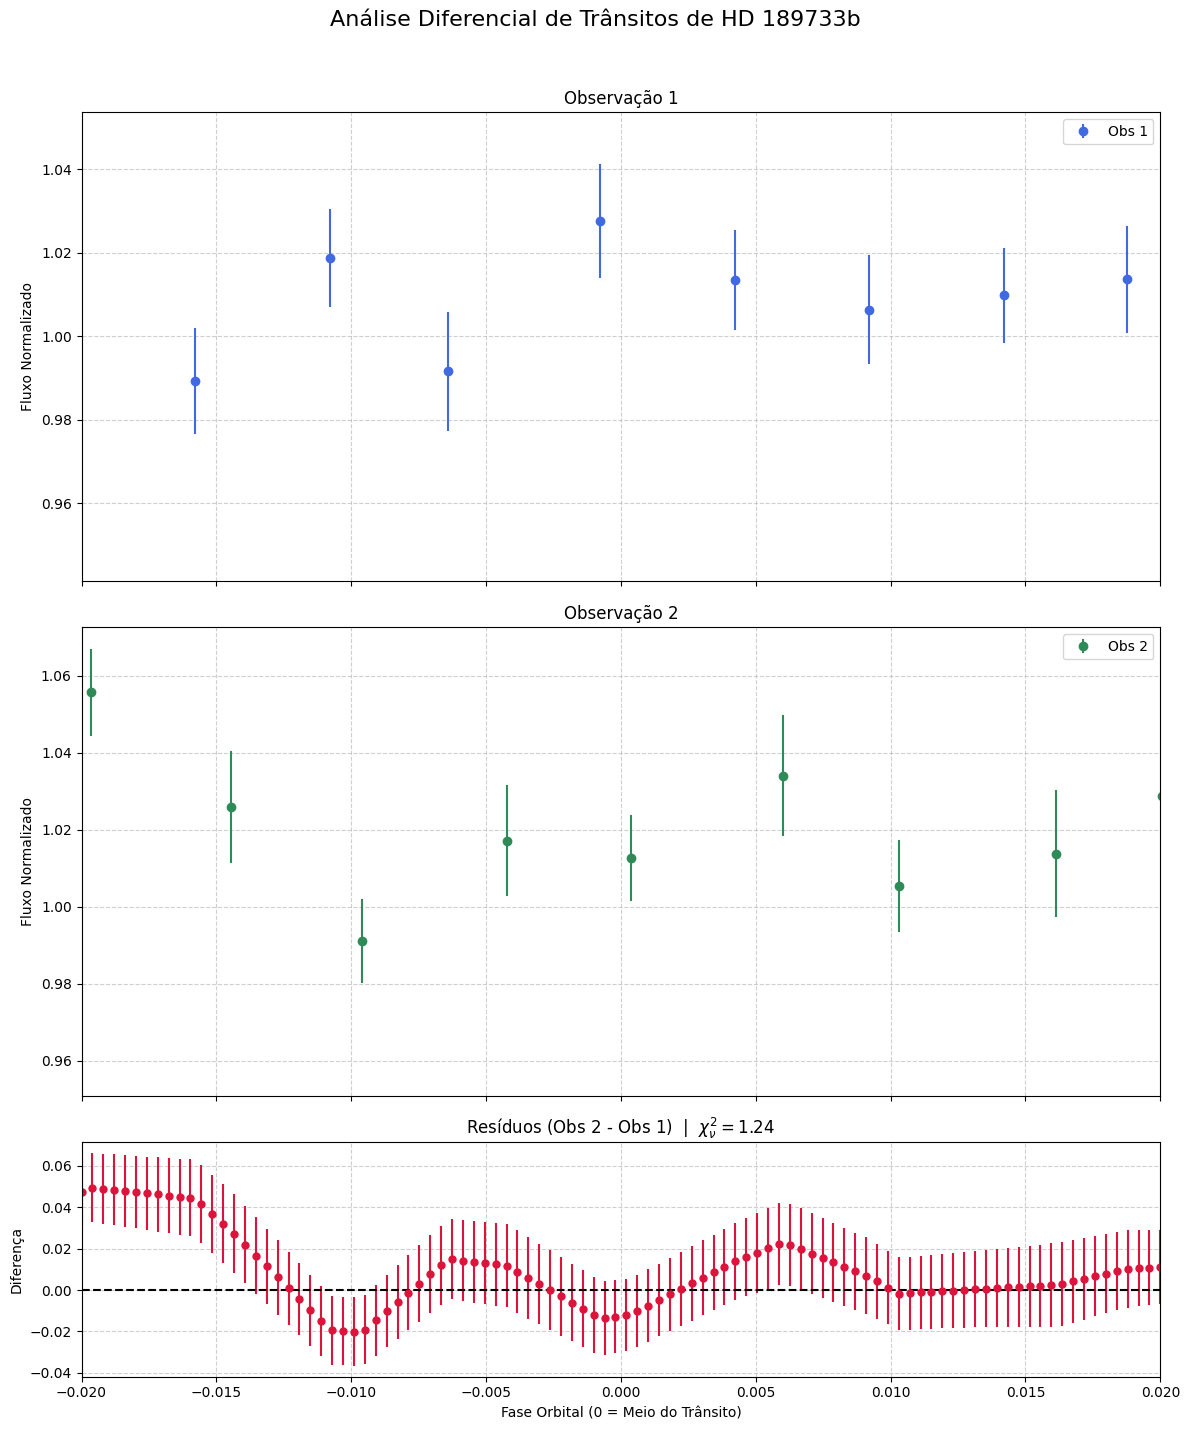

In [199]:
# --- 1. CONFIGURAÇÃO PRINCIPAL ---
pasta_obs_1 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
t0_obs_1 = 1.5058

pasta_obs_2 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/'
t0_obs_2 = 7.8336

parametros_gerais = { 'periodo': 2.21857520 }

# --- 2. PROCESSAR E SUBTRAIR (Como antes) ---
fase1, fluxo1, erro1 = processar_curva_de_luz(pasta_obs_1, t0_obs_1, parametros_gerais['periodo'])
fase2, fluxo2, erro2 = processar_curva_de_luz(pasta_obs_2, t0_obs_2, parametros_gerais['periodo'])

fase_comum = np.linspace(-0.02, 0.02, num=100)
fluxo1_interp = np.interp(fase_comum, fase1, fluxo1)
erro1_interp = np.interp(fase_comum, fase1, erro1)
fluxo2_interp = np.interp(fase_comum, fase2, fluxo2)
erro2_interp = np.interp(fase_comum, fase2, erro2)

fluxo_residuo = fluxo2_interp - fluxo1_interp
erro_residuo = np.sqrt(erro1_interp**2 + erro2_interp**2)

# --- NOVO! 3. CÁLCULO DA MÉTRICA DE QUI-QUADRADO ---

# Nosso modelo (E) é a hipótese de "nenhuma diferença", ou seja, uma linha em y=0
modelo = np.zeros_like(fluxo_residuo)

# Nossos dados observados (O) são os resíduos
dados_observados = fluxo_residuo

# Nossa incerteza (sigma) é o erro dos resíduos
incerteza = erro_residuo

# Calcular o Qui-quadrado (Chi-squared)
qui_quadrado = np.sum(((dados_observados - modelo) / incerteza)**2)

# Calcular os graus de liberdade (número de pontos - número de parâmetros do modelo)
# Nosso modelo y=0 tem 1 parâmetro (a média, que é zero).
graus_de_liberdade = len(dados_observados) - 1

# Calcular o Qui-quadrado Reduzido
qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade

print("-" * 50)
print("ANÁLISE ESTATÍSTICA DOS RESÍDUOS")
print("-" * 50)
print(f"Valor do Qui-quadrado Reduzido (χ²ν): {qui_quadrado_reduzido:.4f}")

# Interpretação automática do resultado
if 0.7 <= qui_quadrado_reduzido <= 1.5:
    print("Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença")
    print("entre as curvas é consistente com o ruído esperado.")
    print("==> Conclusão Numérica: Os dois trânsitos são estatisticamente idênticos.")
elif qui_quadrado_reduzido > 1.5:
    print("Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere")
    print("que a diferença entre as curvas é maior que o ruído esperado.")
    print("==> Conclusão Numérica: A variação entre os trânsitos pode ser real.")
else: # qui_quadrado_reduzido < 0.7
    print("Interpretação: Interessante. Um valor muito menor que 1.0 pode indicar")
    print("que as barras de erro dos dados foram superestimadas.")
print("-" * 50)


# --- 4. PLOTAGEM FINAL (Como antes) ---
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
# ... (cole o código de plotagem da resposta anterior aqui)
fig.suptitle('Análise Diferencial de Trânsitos de HD 189733b', fontsize=16)
axs[0].errorbar(fase1, fluxo1, yerr=erro1, fmt='o', color='royalblue', label='Obs 1')
axs[0].set_title('Observação 1')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()
axs[1].errorbar(fase2, fluxo2, yerr=erro2, fmt='o', color='seagreen', label='Obs 2')
axs[1].set_title('Observação 2')
axs[1].set_ylabel('Fluxo Normalizado')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()
axs[2].errorbar(fase_comum, fluxo_residuo, yerr=erro_residuo, fmt='o', color='crimson', markersize=5)
axs[2].axhline(0, color='black', linestyle='--')
axs[2].set_title(f'Resíduos (Obs 2 - Obs 1)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[2].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[2].set_ylabel('Diferença')
axs[2].grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.02, 0.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Análise 3

--------------------------------------------------
ANÁLISE ESTATÍSTICA DOS RESÍDUOS
--------------------------------------------------
Valor do Qui-quadrado Reduzido (χ²ν): 1.7736
Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere
que a diferença entre as curvas é maior que o ruído esperado.
==> Conclusão Numérica: A variação entre os trânsitos pode ser real.
--------------------------------------------------


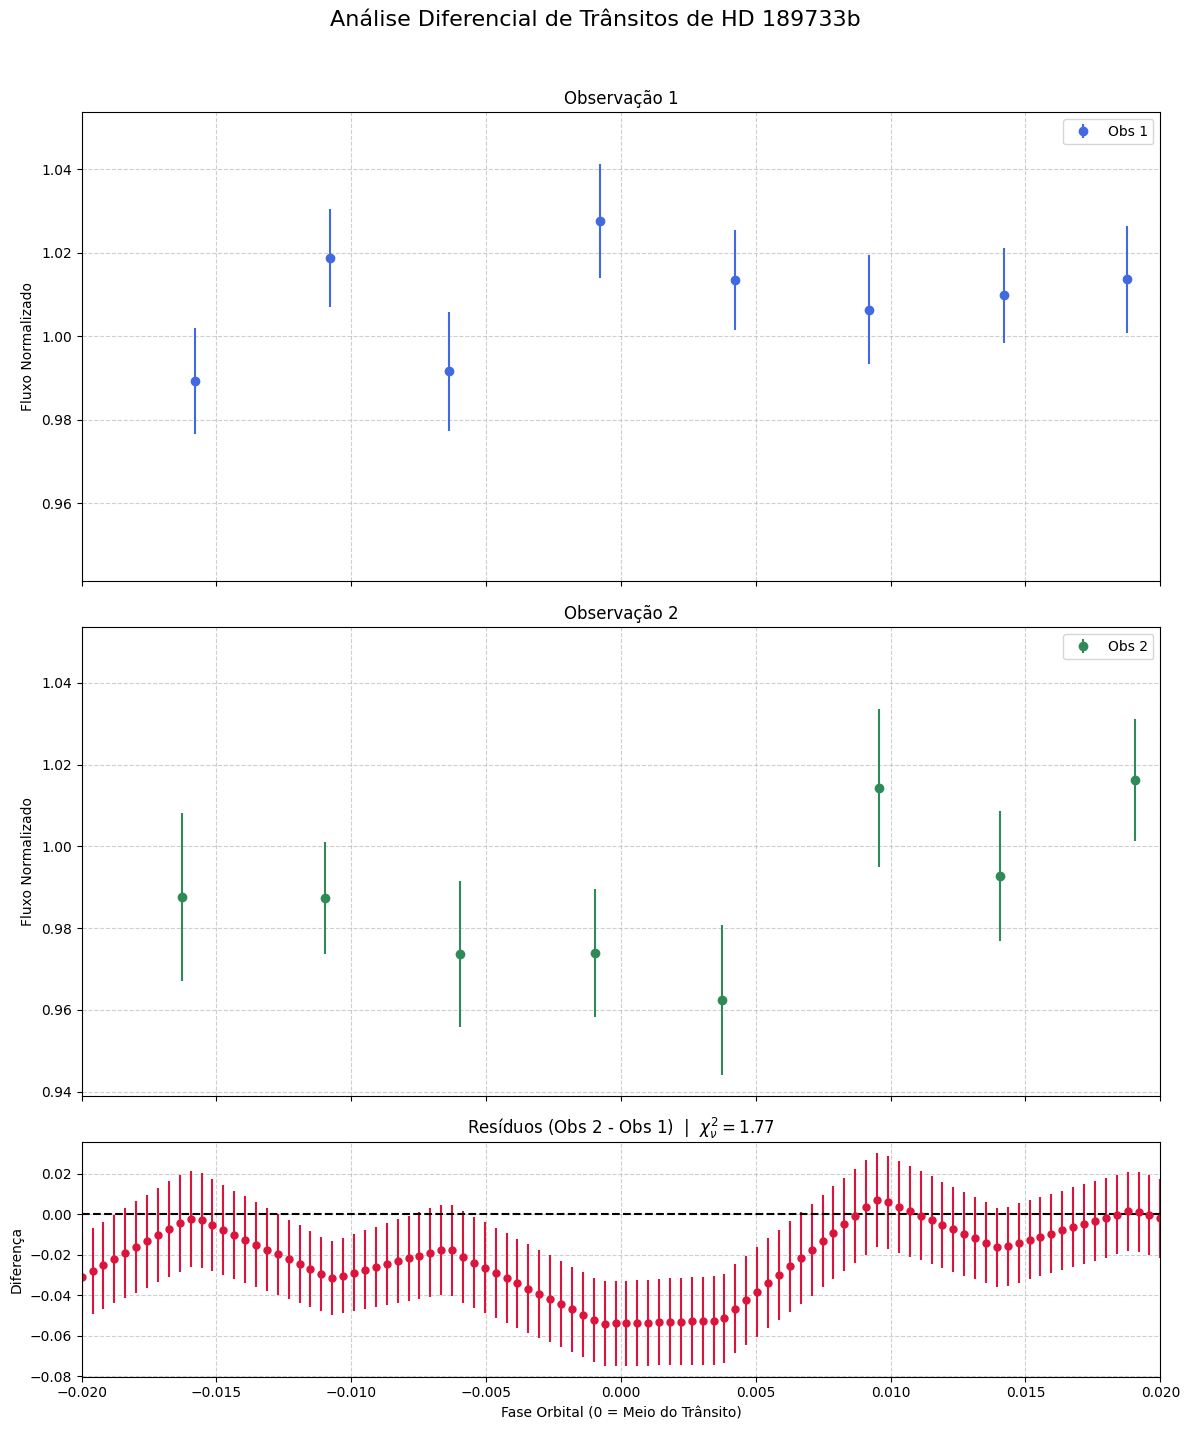

In [200]:
# --- 1. CONFIGURAÇÃO PRINCIPAL ---
pasta_obs_1 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
t0_obs_1 = 1.5058

pasta_obs_2 = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/'
t0_obs_2 = 5.2427

parametros_gerais = { 'periodo': 2.21857520 }

# --- 2. PROCESSAR E SUBTRAIR (Como antes) ---
fase1, fluxo1, erro1 = processar_curva_de_luz(pasta_obs_1, t0_obs_1, parametros_gerais['periodo'])
fase2, fluxo2, erro2 = processar_curva_de_luz(pasta_obs_2, t0_obs_2, parametros_gerais['periodo'])

fase_comum = np.linspace(-0.02, 0.02, num=100)
fluxo1_interp = np.interp(fase_comum, fase1, fluxo1)
erro1_interp = np.interp(fase_comum, fase1, erro1)
fluxo2_interp = np.interp(fase_comum, fase2, fluxo2)
erro2_interp = np.interp(fase_comum, fase2, erro2)

fluxo_residuo = fluxo2_interp - fluxo1_interp
erro_residuo = np.sqrt(erro1_interp**2 + erro2_interp**2)

# --- NOVO! 3. CÁLCULO DA MÉTRICA DE QUI-QUADRADO ---

# Nosso modelo (E) é a hipótese de "nenhuma diferença", ou seja, uma linha em y=0
modelo = np.zeros_like(fluxo_residuo)

# Nossos dados observados (O) são os resíduos
dados_observados = fluxo_residuo

# Nossa incerteza (sigma) é o erro dos resíduos
incerteza = erro_residuo

# Calcular o Qui-quadrado (Chi-squared)
qui_quadrado = np.sum(((dados_observados - modelo) / incerteza)**2)

# Calcular os graus de liberdade (número de pontos - número de parâmetros do modelo)
# Nosso modelo y=0 tem 1 parâmetro (a média, que é zero).
graus_de_liberdade = len(dados_observados) - 1

# Calcular o Qui-quadrado Reduzido
qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade

print("-" * 50)
print("ANÁLISE ESTATÍSTICA DOS RESÍDUOS")
print("-" * 50)
print(f"Valor do Qui-quadrado Reduzido (χ²ν): {qui_quadrado_reduzido:.4f}")

# Interpretação automática do resultado
if 0.7 <= qui_quadrado_reduzido <= 1.5:
    print("Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença")
    print("entre as curvas é consistente com o ruído esperado.")
    print("==> Conclusão Numérica: Os dois trânsitos são estatisticamente idênticos.")
elif qui_quadrado_reduzido > 1.5:
    print("Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere")
    print("que a diferença entre as curvas é maior que o ruído esperado.")
    print("==> Conclusão Numérica: A variação entre os trânsitos pode ser real.")
else: # qui_quadrado_reduzido < 0.7
    print("Interpretação: Interessante. Um valor muito menor que 1.0 pode indicar")
    print("que as barras de erro dos dados foram superestimadas.")
print("-" * 50)


# --- 4. PLOTAGEM FINAL (Como antes) ---
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
# ... (cole o código de plotagem da resposta anterior aqui)
fig.suptitle('Análise Diferencial de Trânsitos de HD 189733b', fontsize=16)
axs[0].errorbar(fase1, fluxo1, yerr=erro1, fmt='o', color='royalblue', label='Obs 1')
axs[0].set_title('Observação 1')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()
axs[1].errorbar(fase2, fluxo2, yerr=erro2, fmt='o', color='seagreen', label='Obs 2')
axs[1].set_title('Observação 2')
axs[1].set_ylabel('Fluxo Normalizado')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()
axs[2].errorbar(fase_comum, fluxo_residuo, yerr=erro_residuo, fmt='o', color='crimson', markersize=5)
axs[2].axhline(0, color='black', linestyle='--')
axs[2].set_title(f'Resíduos (Obs 2 - Obs 1)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[2].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[2].set_ylabel('Diferença')
axs[2].grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.02, 0.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()